In [2]:
import pandas as pd
import glob
import os

In [3]:
file_path = "../Data/2차전처리_버스데이터.csv"

# 파일 존재 여부 먼저 확인
print(os.path.exists(file_path))

# True가 나오면 실행
df_bus = pd.read_csv(file_path, encoding="utf-8-sig")

df_bus.head(5)

True


C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2893020837.py:7: DtypeWarning: Columns (0: 정류소번호) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bus = pd.read_csv(file_path, encoding="utf-8-sig")


,승하차일자,관할관청,행정동,정류소ID,정류소번호,정류소명,승차합계,초승,환승,하차
0,2023-01,성남시,성남동,205000120,6163.0,(구)성남동주민센터,103,99,4,106
1,2023-01,성남시,서현1동,206000436,7387.0,AK플라자2층,353,203,150,454
2,2023-01,성남시,삼평동,206000677,7034.0,H스퀘어.삼환하이펙스,1,1,0,25
3,2023-01,성남시,삼평동,206000678,7479.0,H스퀘어.삼환하이펙스,15,14,1,2
4,2023-01,성남시,시흥동,204000342,5333.0,I_SQUARE.창업주택,5,3,2,49


In [4]:
# 제일 많이 이용하는 곳
top10 = df_bus.groupby(['행정동', '정류소명'], as_index=False)['승차합계'].sum()

top10.sort_values('승차합계', ascending=False).head(10)

,행정동,정류소명,승차합계
705,야탑1동,야탑역.종합버스터미널(전면),12281251
706,야탑1동,야탑역.종합버스터미널(후면),10058504
266,백현동,판교역.낙생육교.현대백화점,8171270
872,이매1동,이매촌한신.서현역.AK프라자,7132904
487,서현1동,이매촌한신.서현역.AK프라자,7132904
519,성남동,모란역2.3번출구,6604519
115,금곡동,미금역.청솔마을.2001아울렛,6474268
476,서현1동,서현역.AK플라자,6296355
904,정자1동,정자역,6181445
153,금광2동,남한산성입구역.법원검찰청,4526815


## 행정동별 시계열 추이

In [5]:
dong = df_bus.groupby('행정동', as_index=False)['승차합계'].sum()
dong_top10 = dong.sort_values('승차합계', ascending=False).head(10)
dong_top10 

,행정동,승차합계
28,성남동,32416973
42,야탑1동,27329924
19,삼평동,25003445
24,서현1동,21775532
54,정자1동,16713182
5,금광1동,13513820
14,백현동,12666601
51,이매1동,12211225
20,상대원1동,11425958
2,구미1동,11198091


C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2446967420.py:34: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2446967420.py:34: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2446967420.py:34: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2446967420.py:34: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2446967420.py:34: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2446967420.py:34: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from f

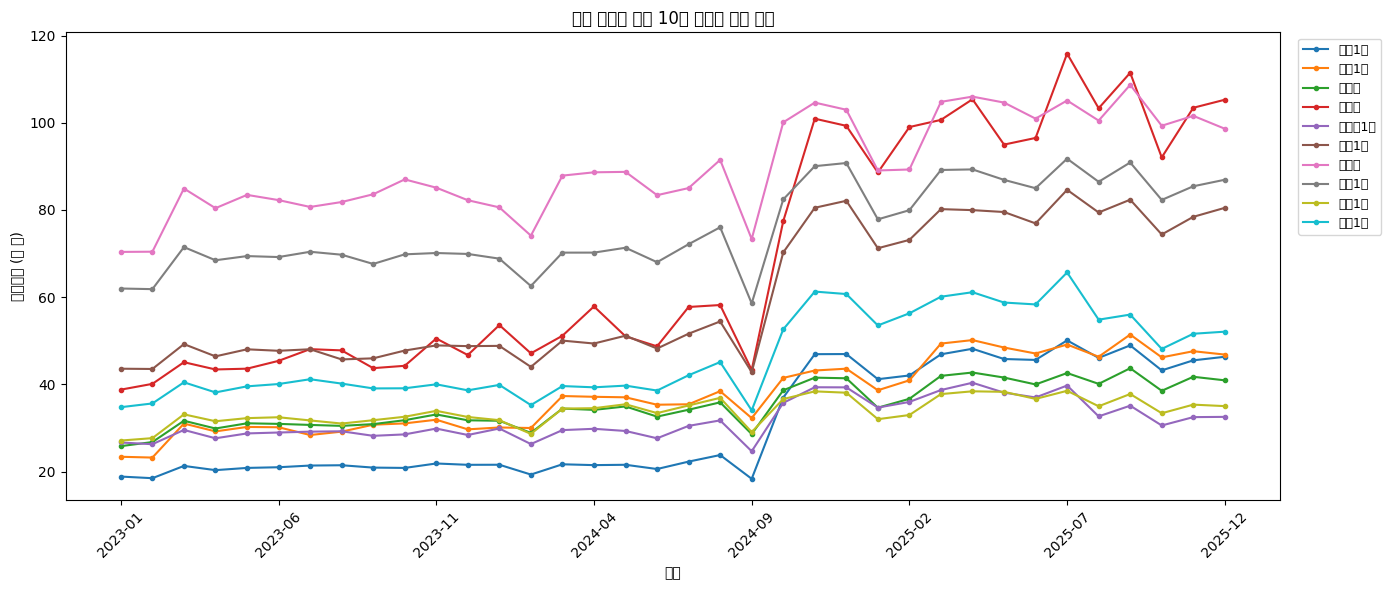

In [6]:
import matplotlib.pyplot as plt
# 1. 월별 행정동별 승차합계
dong_m = (
    df_bus
    .groupby(['행정동', '승하차일자'])['승차합계']
    .sum()
    .reset_index()
)

# 2. 행정동별 평균 월 이용량
slope_df = (
    dong_m
    .groupby('행정동')['승차합계']
    .mean()
    .sort_values(ascending=False)
)

# 3. 이용량 상위 10개 동
top10_list = slope_df.head(10).index.tolist()

# 4. 그래프
pivot = (
    dong_m[dong_m['행정동'].isin(top10_list)]
    .pivot(index='승하차일자', columns='행정동', values='승차합계') / 1e4
)

pivot.plot(figsize=(14, 6), marker='o', ms=3)

plt.title('버스 이용량 상위 10개 행정동 월별 추이', fontsize=12)
plt.ylabel('승차합계 (만 명)')
plt.xlabel('연월')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

 - 2024년 10월 = 구조적 변화 시점 → 정책 / 노선 변경 / 외부 이벤트 가능성 높음
 -  행정동 간 격차는 계속 유지 → 상위는 계속 상위, 하위는 계속 하위
 -  전체 수요는 증가 추세 → 특히 2025년은 고점 유지 상태

C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\3008389482.py:41: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\3008389482.py:41: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\3008389482.py:41: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\3008389482.py:41: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\3008389482.py:41: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\3008389482.py:41: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font

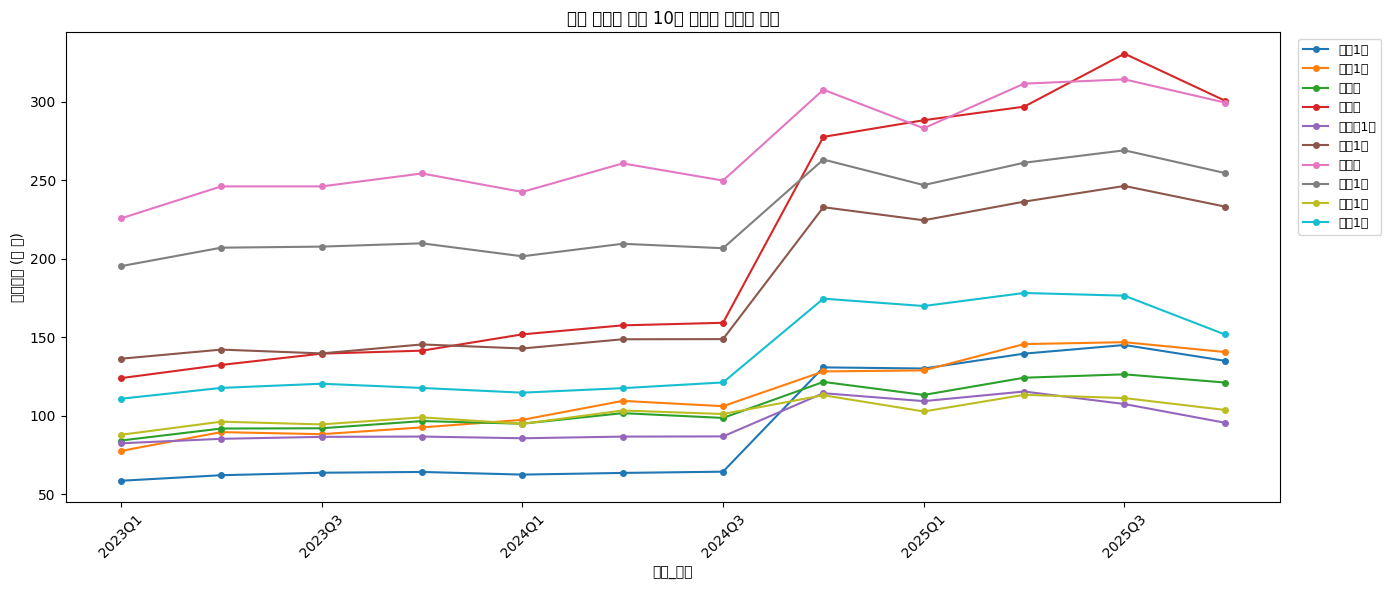

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 날짜 변환 + 분기 컬럼 생성
df_bus['승하차일자'] = pd.to_datetime(df_bus['승하차일자'])
df_bus['연도_분기'] = df_bus['승하차일자'].dt.to_period('Q').astype(str)

# 2. 분기별 행정동별 승차합계
dong_q = (
    df_bus
    .groupby(['행정동', '연도_분기'])['승차합계']
    .sum()
    .reset_index()
)

# 3. 행정동별 평균 분기 이용량
slope_df = (
    dong_q
    .groupby('행정동')['승차합계']
    .mean()
    .sort_values(ascending=False)
)

# 4. 이용량 상위 10개 동
top10_list = slope_df.head(10).index.tolist()

# 5. 그래프용 pivot
pivot = (
    dong_q[dong_q['행정동'].isin(top10_list)]
    .pivot(index='연도_분기', columns='행정동', values='승차합계') / 1e4
)

# 6. 시각화
pivot.plot(figsize=(14, 6), marker='o', ms=4)

plt.title('버스 이용량 상위 10개 행정동 분기별 추이', fontsize=12)
plt.ylabel('승차합계 (만 명)')
plt.xlabel('연도_분기')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

 - 2024년 3분기 = 구조적 변화 시점 → 정책 / 노선 변경 / 외부 이벤트 가능성 높음
 -  행정동 간 격차는 계속 유지 → 상위는 계속 상위, 하위는 계속 하위
 -  전체 수요는 증가 추세 → 특히 2025년은 고점 유지 상태

C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2878794456.py:22: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2878794456.py:22: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2878794456.py:22: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2878794456.py:22: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2878794456.py:22: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\2878794456.py:22: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from 

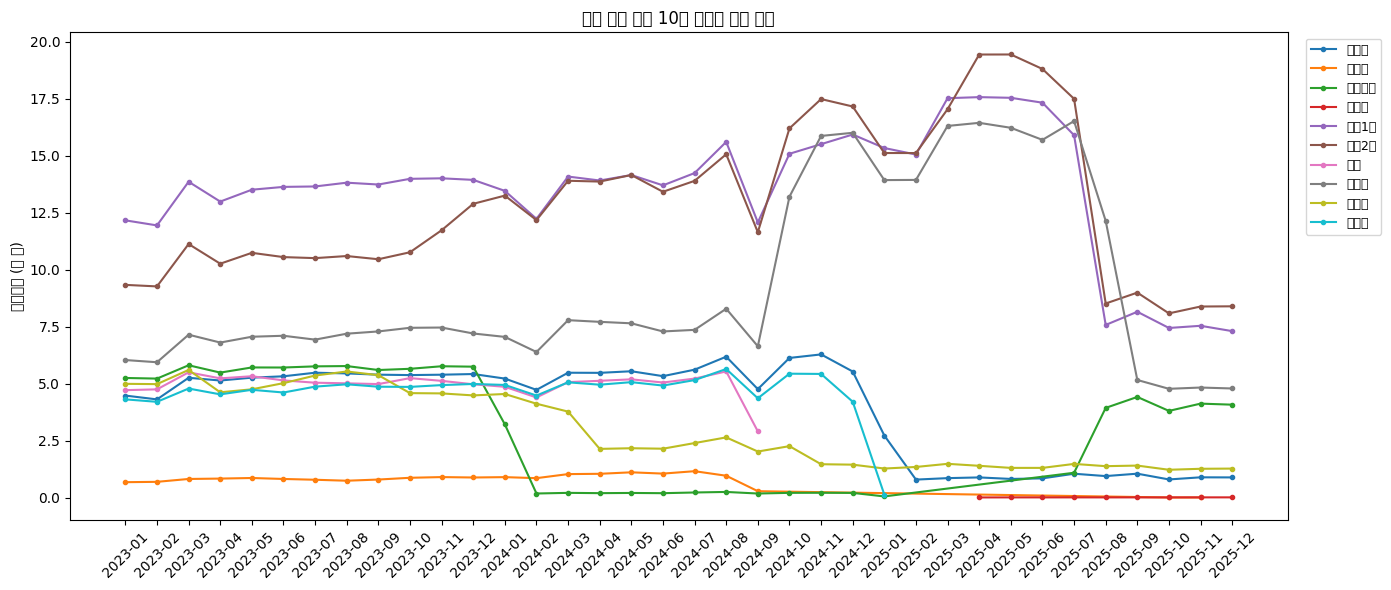

In [8]:
# 1. pivot 만들기
pivot = dong_m.pivot(index='승하차일자', columns='행정동', values='승차합계')

# 2. 기울기 계산 (감소/증가 판단)
slope = pivot.apply(lambda x: x.diff().mean())

# 3. 감소 상위 10개
dec10_list = slope.nsmallest(10).index.tolist()

# 감소 추세 강한 10개 동
fig, ax = plt.subplots(figsize=(14, 6))

for dong, grp in dong_m[dong_m['행정동'].isin(dec10_list)].groupby('행정동'):
    ax.plot(grp['승하차일자'], grp['승차합계'] / 1e4,
            marker='o', ms=3, label=dong)

ax.set_title('감소 추세 강한 10개 행정동 월별 추이', fontsize=12)
ax.set_ylabel('승차합계 (만 명)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


- 버스 이용량 감소 = 해당 상권으로 유입되는 소비자 수 감소
- 감소 패턴에 따른 상업 젠트리피케이션 해석:

  1. **급락 후 회복** → 재개발 공사 중 일시적 소비 이탈 후 새로운 상권 형성 → 업종 교체 가능성
  2. **급락 후 낮은 수준 유지** → 기존 상권 붕괴 후 소비자 미복귀 → 소상공인 이탈 완료된 지역
  3. **점진적 감소** → 상권 서서히 약화 중 → 소상공인 이탈 진행 중인 초기 신호

C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\4100039026.py:39: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\4100039026.py:39: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\4100039026.py:39: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\4100039026.py:39: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\4100039026.py:39: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cute3\AppData\Local\Temp\ipykernel_7812\4100039026.py:39: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from 

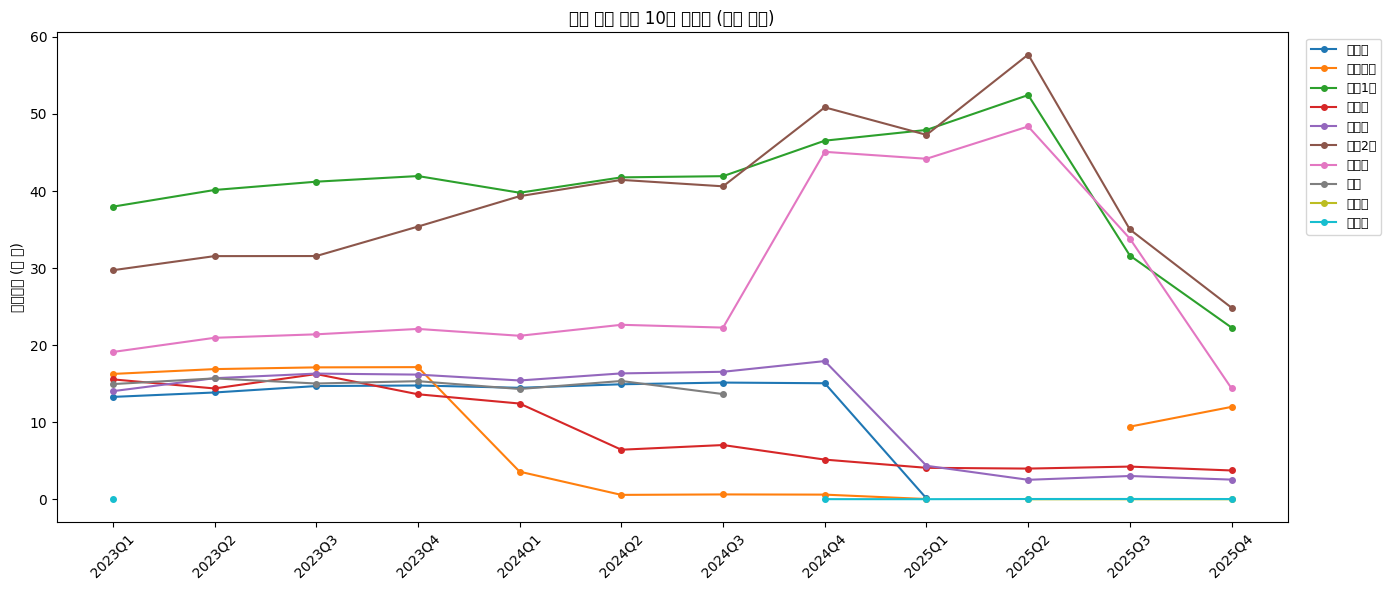

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 날짜 변환 + 분기 생성
dong_m['승하차일자'] = pd.to_datetime(dong_m['승하차일자'])
dong_m['연도_분기'] = dong_m['승하차일자'].dt.to_period('Q').astype(str)

# 2. 분기 기준 pivot
pivot = (
    dong_m
    .groupby(['연도_분기', '행정동'])['승차합계']
    .sum()   # 👉 평균 보고 싶으면 .mean()
    .unstack()
)

# 3. 기울기 계산 (분기 기준)
slope = pivot.apply(lambda x: x.diff().mean())

# 4. 감소 상위 10개
dec10_list = slope.nsmallest(10).index.tolist()

# 5. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

for dong in dec10_list:
    ax.plot(
        pivot.index,               # 분기
        pivot[dong] / 1e4,
        marker='o',
        ms=4,
        label=dong
    )

ax.set_title('감소 추세 강한 10개 행정동 (분기 기준)', fontsize=12)
ax.set_ylabel('승차합계 (만 명)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- 버스 이용량 감소 = 해당 상권으로 유입되는 소비자 수 감소
- 감소 패턴에 따른 상업 젠트리피케이션 해석:

  1. **급락 후 회복** → 재개발 공사 중 일시적 소비 이탈 후 새로운 상권 형성 → 업종 교체 가능성
  2. **급락 후 낮은 수준 유지** → 기존 상권 붕괴 후 소비자 미복귀 → 소상공인 이탈 완료된 지역
  3. **점진적 감소** → 상권 서서히 약화 중 → 소상공인 이탈 진행 중인 초기 신호

##  초승 vs 환승 비율 — 행정동

In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

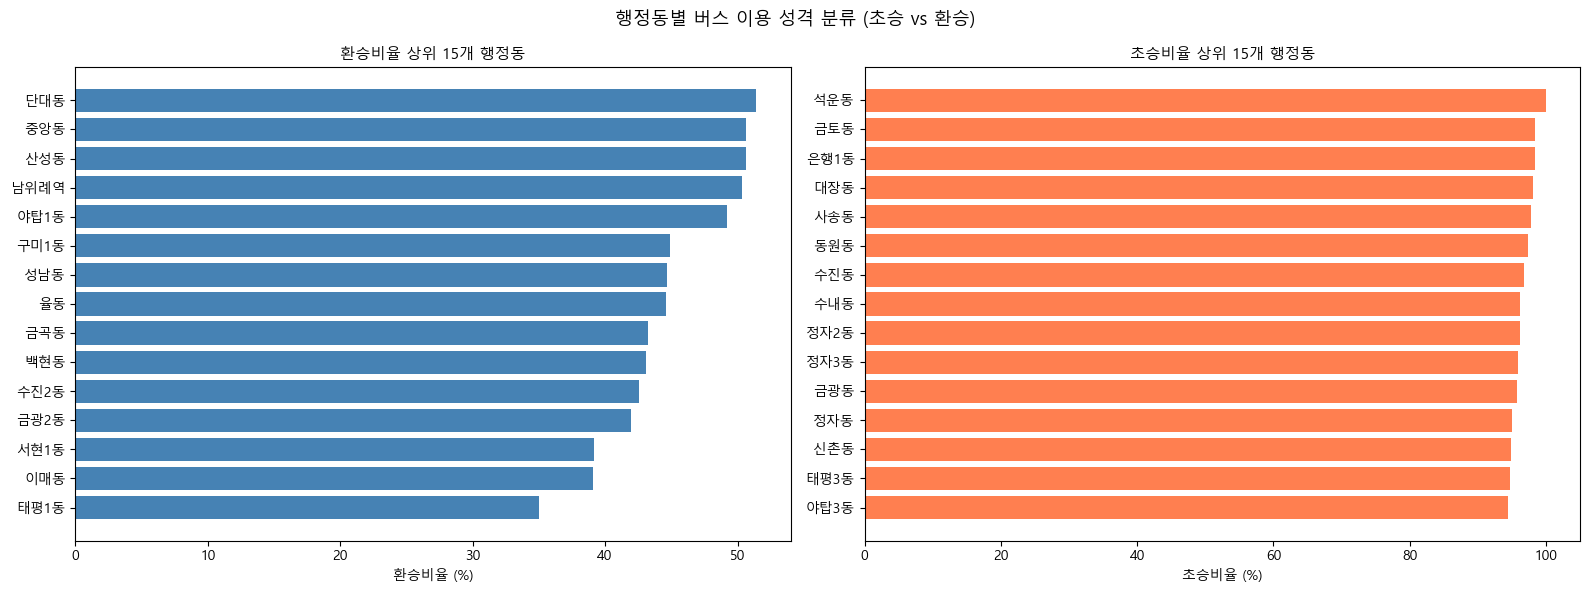

In [11]:
dong_agg = (
    df_bus
    .groupby('행정동')[['승차합계', '초승', '환승']]
    .sum()
)
dong_agg['초승비율(%)'] = dong_agg['초승'] / dong_agg['승차합계'] * 100
dong_agg['환승비율(%)'] = dong_agg['환승'] / dong_agg['승차합계'] * 100
dong_agg = dong_agg.sort_values('환승비율(%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_trans = dong_agg.head(15)
axes[0].barh(top_trans.index[::-1], top_trans['환승비율(%)'][::-1], color='steelblue')
axes[0].set_title('환승비율 상위 15개 행정동', fontsize=11)
axes[0].set_xlabel('환승비율 (%)')

top_orig = dong_agg.sort_values('초승비율(%)', ascending=False).head(15)
axes[1].barh(top_orig.index[::-1], top_orig['초승비율(%)'][::-1], color='coral')
axes[1].set_title('초승비율 상위 15개 행정동', fontsize=11)
axes[1].set_xlabel('초승비율 (%)')

plt.suptitle('행정동별 버스 이용 성격 분류 (초승 vs 환승)', fontsize=13)
plt.tight_layout()
plt.show()


## 행정동별 버스 승차 로그 변화율 (시작 vs 끝)

- 기준: 분석 시작월(2023-01) 대비 최종월 승차량 변화를 로그 변화율로 측정
- 이용량 1,000 미만 소규모 행정동 제외 (통계적 왜곡 방지)
- 파란색 → 소비자 유입 증가 / 빨간색 → 소비자 이탈

### 증가 상위 10개 동
- log_rate 양수 → 외부 소비자 유입이 순증한 상권 → 임대료 상승 압력 높은 지역

### 감소 하위 10개 동
- log_rate 음수 → 소비자가 이탈한 상권 → 소상공인 매출 감소·폐업 가속 가능성

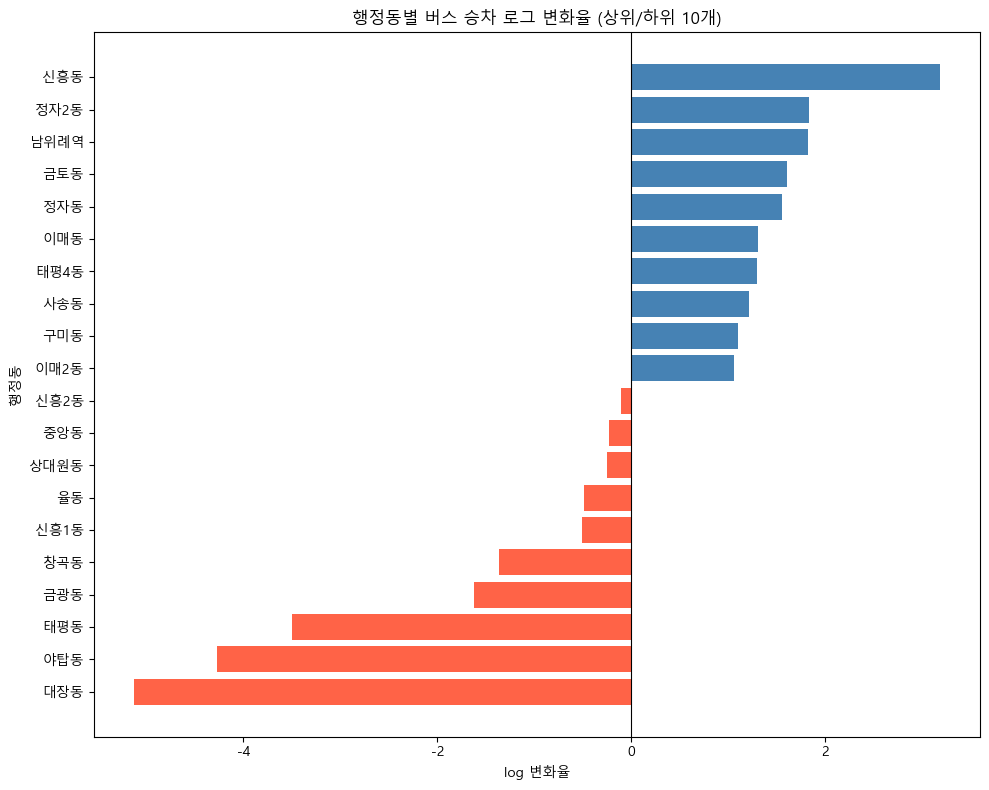

In [12]:
import numpy as np
import pandas as pd

#  행정동별 시작 / 끝 값
dong_start = dong_m.sort_values('승하차일자').groupby('행정동').first()
dong_end   = dong_m.sort_values('승하차일자').groupby('행정동').last()

#  합치기
df_rate = pd.DataFrame({
    'start': dong_start['승차합계'],
    'end':   dong_end['승차합계']
})

#  필터 (너무 작은 값 제거)
df_rate = df_rate[df_rate['start'] > 1000]

# 로그 변화율
df_rate['log_rate'] = np.log(df_rate['end'] / df_rate['start'])


df_rate = df_rate.sort_values('log_rate', ascending=False)

import matplotlib.pyplot as plt

top10    = df_rate.head(10)
bottom10 = df_rate.tail(10)
plot_df  = pd.concat([top10, bottom10])

colors = ['steelblue' if x > 0 else 'tomato' for x in plot_df['log_rate']]

plt.figure(figsize=(10, 8))
plt.barh(plot_df.index, plot_df['log_rate'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)

plt.title('행정동별 버스 승차 로그 변화율 (상위/하위 10개)')
plt.xlabel('log 변화율')
plt.ylabel('행정동')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 해석

- **이용량 증가 지역** → 외부 소비자 유입이 늘고 있는 상권 → 임대료 상승 압력이 높아지는 곳
- **이용량 감소 지역** → 소비자가 이탈한 상권 → 소상공인 매출 감소 → 폐업·이탈 가속 가능성

- 같은 행정동 내에서도 증가·감소가 공존하는 경우 → 상권이 특정 구역으로 재편되는 중

## 행정동 × 연월 히트맵


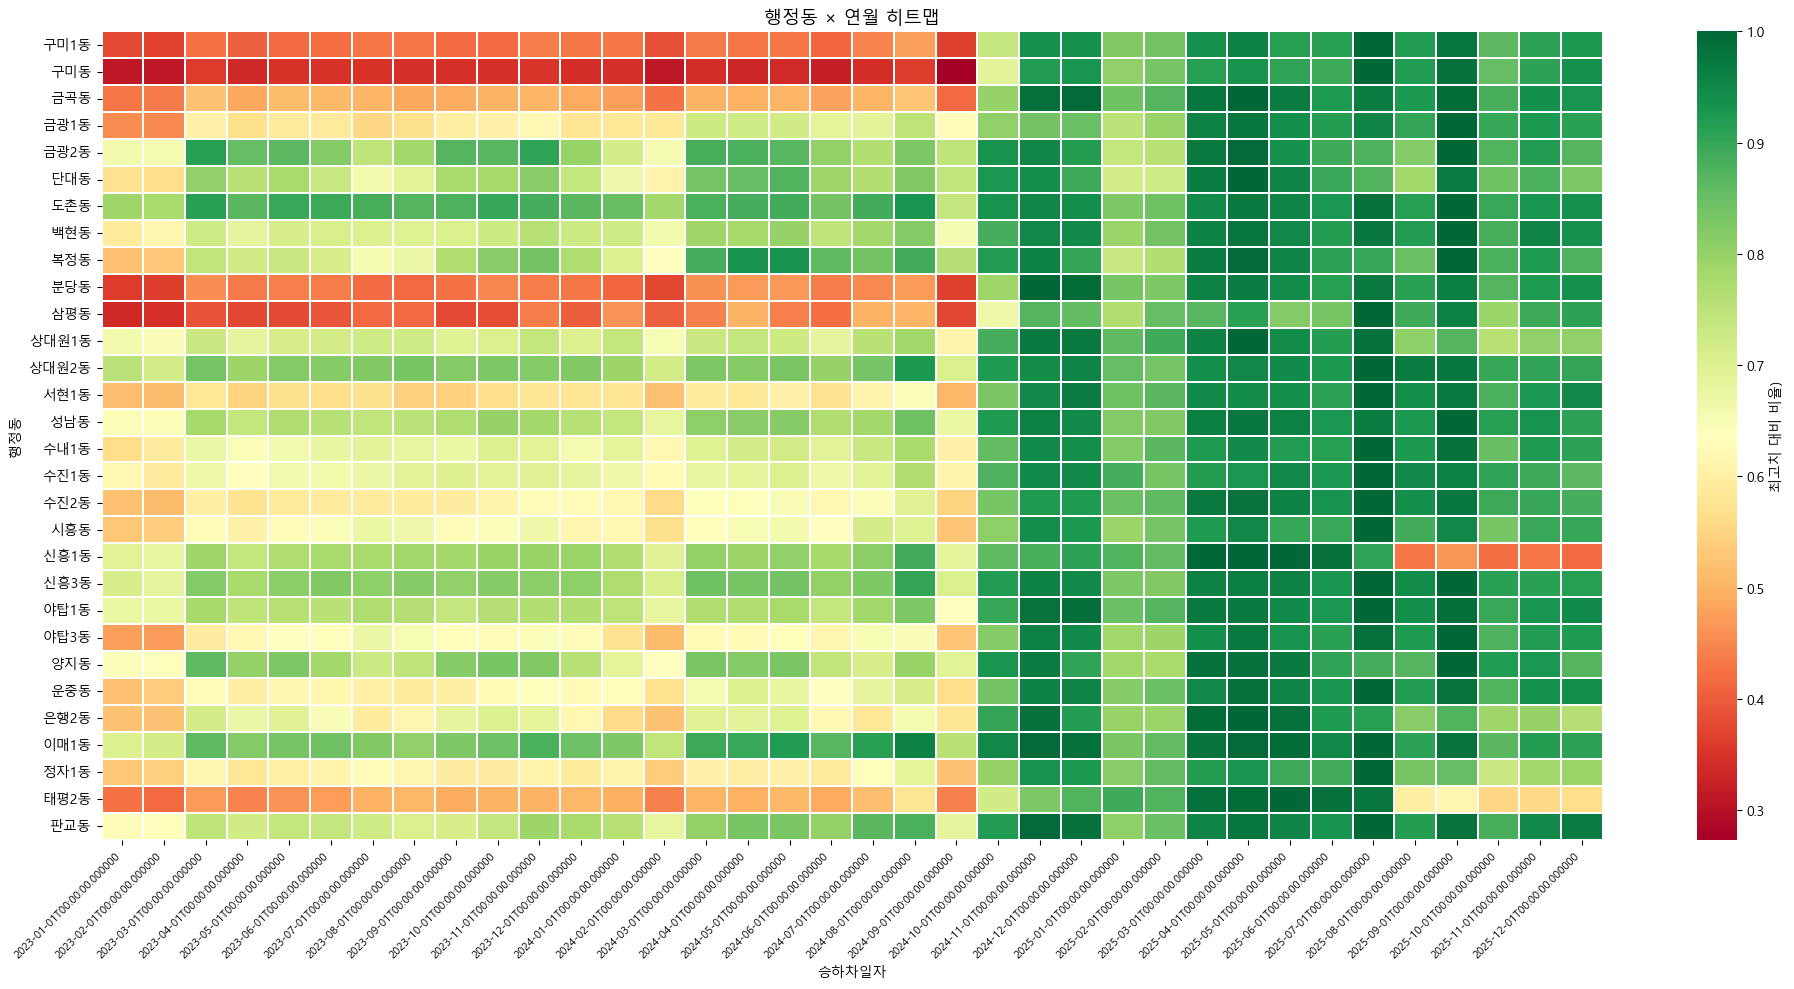

In [13]:
import seaborn as sns
top30_list = slope_df.nlargest(30).index.tolist()

pivot = (
    dong_m[dong_m['행정동'].isin(top30_list)]
    .pivot(index='행정동', columns='승하차일자', values='승차합계')
)
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(pivot_norm, cmap='RdYlGn', ax=ax, linewidths=0.3,
            cbar_kws={'label': '최고치 대비 비율)'})
ax.set_title('행정동 × 연월 히트맵', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


- 2023년 ~ 2024년 초반:  
  →  빨강,  노랑 구간이 많음  
  → 각 행정동 기준으로 이용량이 상대적으로 낮은 시기  

- 2024년 10월 이후:  
  →  초록 구간이 대부분  
  → 각 행정동 기준으로 이용량이 최고 수준에 근접하거나 회복된 상태

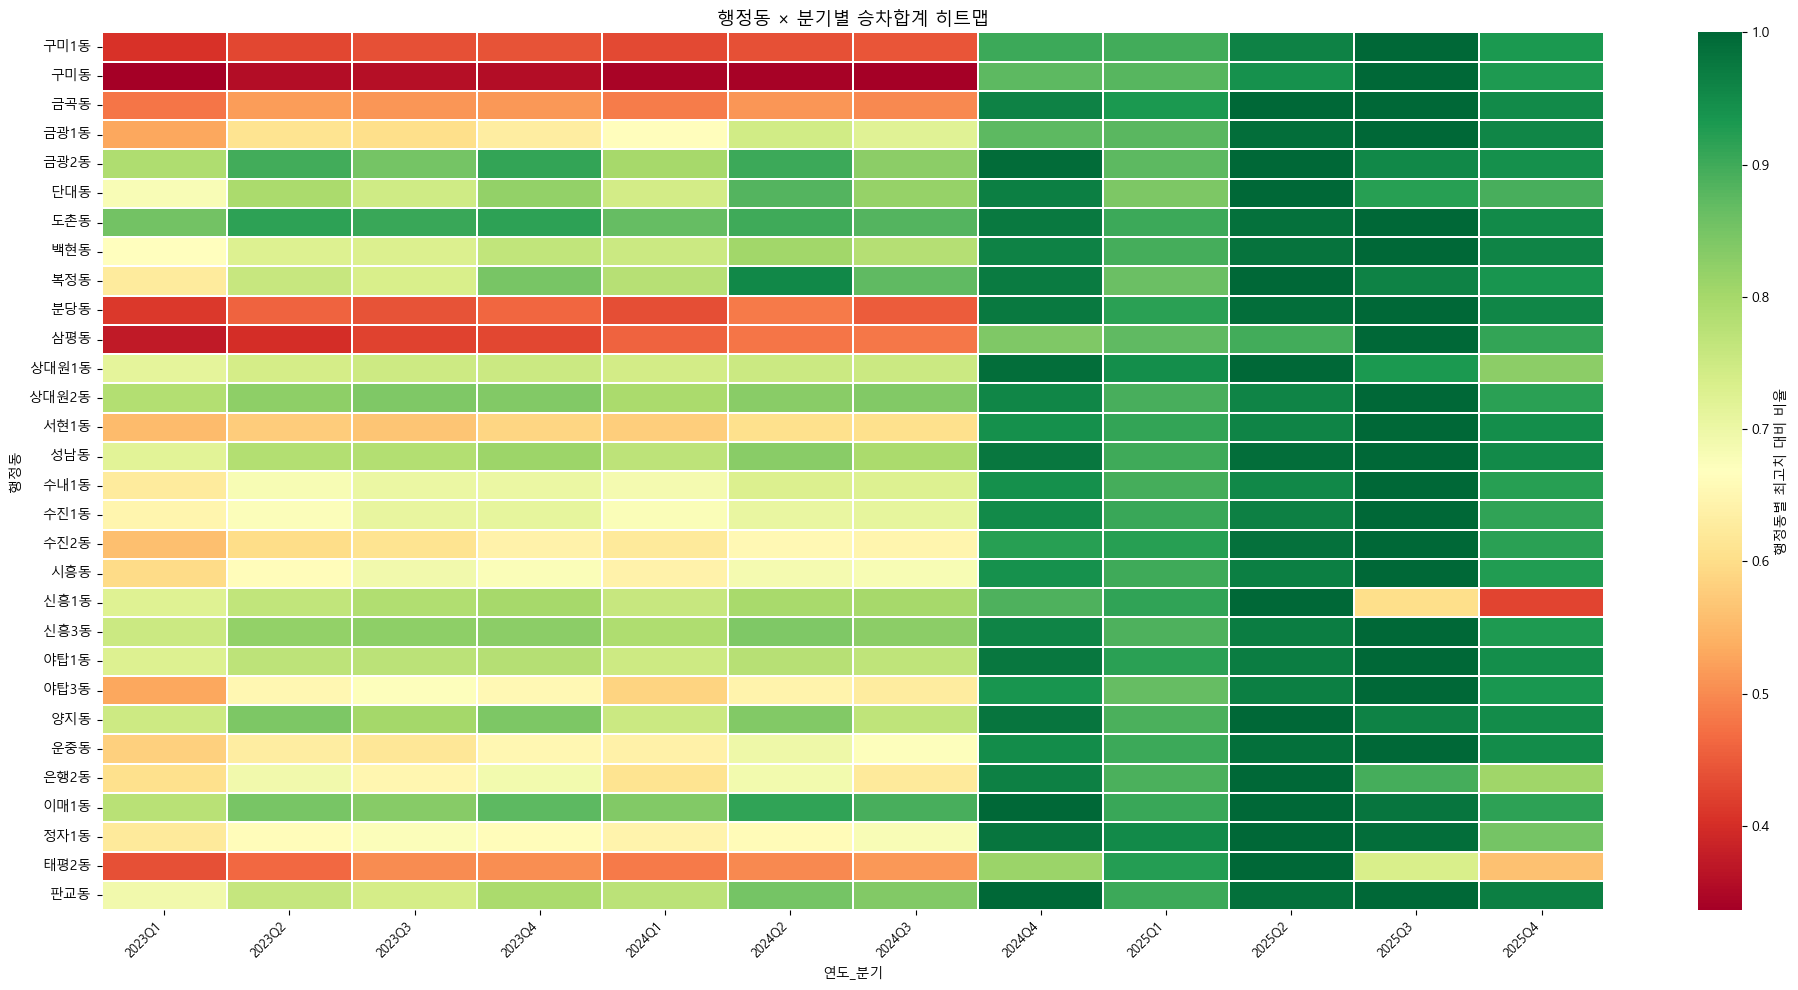

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 날짜 변환
dong_m['승하차일자'] = pd.to_datetime(dong_m['승하차일자'])

# 분기 컬럼 생성
dong_m['연도_분기'] = dong_m['승하차일자'].dt.to_period('Q').astype(str)

# slope_df가 Series일 때
top30_list = slope_df.nlargest(30).index.tolist()

# 분기별 승차합계 집계
pivot = (
    dong_m[dong_m['행정동'].isin(top30_list)]
    .groupby(['행정동', '연도_분기'])['승차합계']
    .sum()
    .unstack()
)

# 행정동별 최고치 대비 비율
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

# 히트맵
fig, ax = plt.subplots(figsize=(20, 10))

sns.heatmap(
    pivot_norm,
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': '행정동별 최고치 대비 비율'}
)

ax.set_title('행정동 × 분기별 승차합계 히트맵', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- 2023년 1분기 ~ 2024년 3분기:  
  →  빨강,  노랑 구간이 많음  
  → 각 행정동 기준으로 이용량이 상대적으로 낮은 시기  

- 2024년 3분기 이후:  
  →  초록 구간이 대부분  
  → 각 행정동 기준으로 이용량이 최고 수준에 근접하거나 회복된 상태

## 행정동 내 정류소 이용 집중도 (HHI)

- HHI(허핀달-허시만 지수): 시장 내 모든 기업의 시장점유율을 각각 제곱한 후 합산한 값
    - 즉, 행정동 내 정류소별 이용 비중의 제곱합 (0~1)

In [16]:
# 행정동별 정류소 이용 집중도 (HHI) 계산
stop_total = df_bus.groupby(['행정동', '정류소명'], as_index=False)['승차합계'].sum()

def calc_hhi(group):
    total = group['승차합계'].sum()
    if total == 0:
        return 0
    shares = group['승차합계'] / total
    return (shares ** 2).sum()

hhi_df = (
    stop_total
    .groupby('행정동')
    .apply(calc_hhi)
    .reset_index()
)
hhi_df.columns = ['행정동', 'HHI']

# 정류소 수도 같이 확인
stop_cnt = stop_total.groupby('행정동')['정류소명'].count().reset_index()
stop_cnt.columns = ['행정동', '정류소수']

hhi_df = hhi_df.merge(stop_cnt, on='행정동').sort_values('HHI', ascending=False)
hhi_df.head(10)

,행정동,HHI,정류소수
27,석운동,1.000000,1
26,서현동,1.000000,1
9,남위례역,1.000000,1
49,은행1동,1.000000,1
53,이매동,1.000000,1
48,율동,1.000000,1
13,동원동,0.995641,2
17,사송동,0.710403,2
58,중앙동,0.654579,13
0,갈현동,0.639442,2


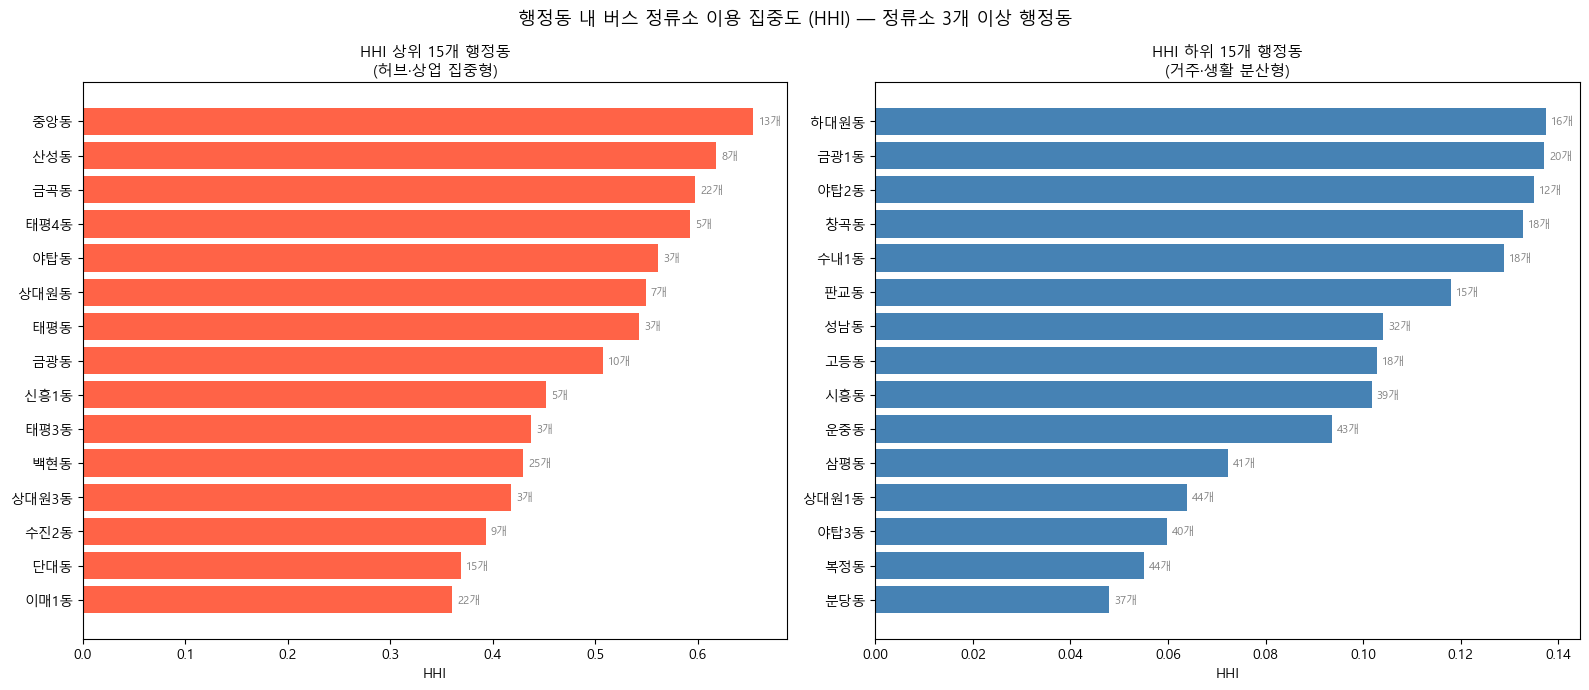

In [17]:
import matplotlib.pyplot as plt

# 정류소 1개짜리는 HHI=1로 자동이라 의미 없음 → 제외
hhi_filtered = hhi_df[hhi_df['정류소수'] >= 3].sort_values('HHI', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# HHI 상위 15개 (허브 집중형)
top15 = hhi_filtered.head(15)
bars0 = axes[0].barh(top15['행정동'][::-1], top15['HHI'][::-1], color='tomato')
axes[0].set_title('HHI 상위 15개 행정동\n(허브·상업 집중형)', fontsize=11)
axes[0].set_xlabel('HHI')
for bar, cnt in zip(bars0, top15['정류소수'][::-1]):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{cnt}개', va='center', fontsize=8, color='gray')

# HHI 하위 15개 (분산형)
bot15 = hhi_filtered.tail(15).sort_values('HHI')
bars1 = axes[1].barh(bot15['행정동'], bot15['HHI'], color='steelblue')
axes[1].set_title('HHI 하위 15개 행정동\n(거주·생활 분산형)', fontsize=11)
axes[1].set_xlabel('HHI')
for bar, cnt in zip(bars1, bot15['정류소수']):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                 f'{cnt}개', va='center', fontsize=8, color='gray')

plt.suptitle('행정동 내 버스 정류소 이용 집중도 (HHI) — 정류소 3개 이상 행정동', fontsize=13)
plt.tight_layout()
plt.show()

- **HHI 높음** → 소비자가 한두 개 대형 상업 허브(역, 백화점)에만 몰림 → 주변 소규모 상권 경쟁력 약화
- **HHI 낮음** → 소비자가 여러 정류소(골목 상권, 전통시장 등)에 분산 → 소규모 상권이 살아있는 상태
- 상업 젠트리피케이션 진행 시 소규모 상권이 사라지고 대형 허브 중심으로 재편되면서 HHI 상승

### 해석 포인트

- **HHI 높은 동** (집중형): 소비자가 역·쇼핑몰 등 대형 허브에 집중 → 골목 소상공인은 집객력 약화 → 폐업 압력
- **HHI 낮은 동** (분산형): 소비자가 여러 정류소에 분산 → 골목 상권·전통시장이 고르게 살아있는 상태

## 소비자 유입 증가 × 정류소 집중도 산점도 (HHI 분석)



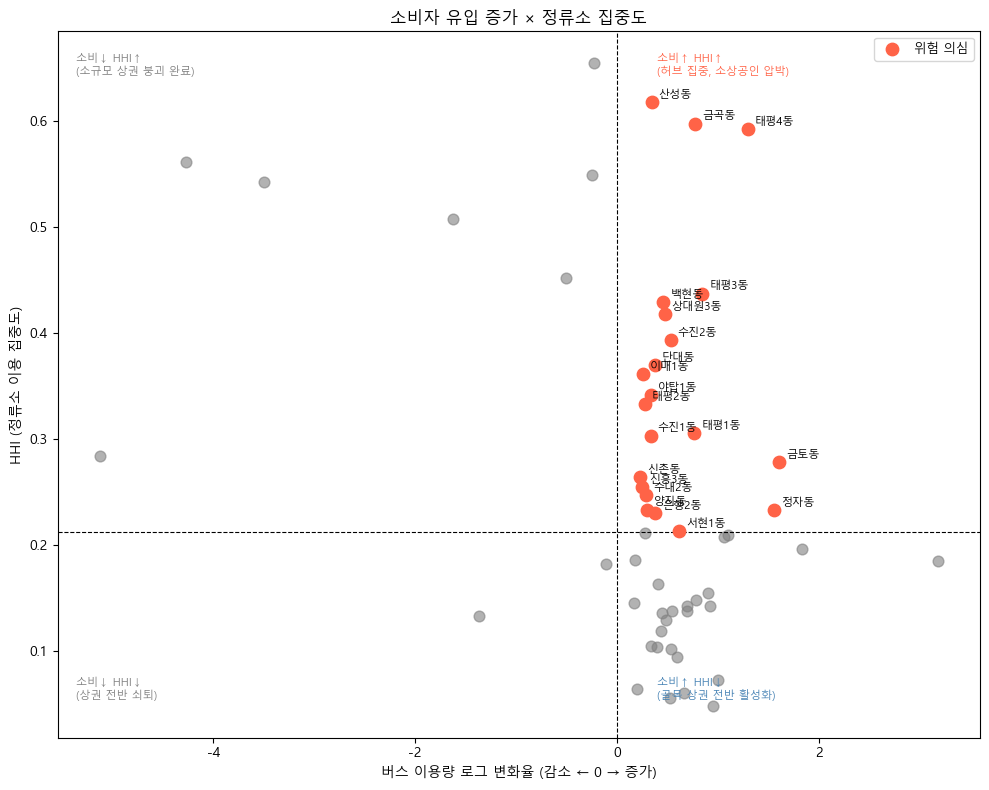

=== 위험 의심 행정동 ===
  행정동  log_rate      HHI  정류소수
  산성동  0.342759 0.618361     8
  금곡동  0.776591 0.597756    22
 태평4동  1.294614 0.592795     5
 태평3동  0.843673 0.437103     3
  백현동  0.460196 0.429510    25
상대원3동  0.471882 0.417935     3
 수진2동  0.531213 0.393373     9
  단대동  0.374017 0.369262    15
 이매1동  0.255662 0.360760    22
 야탑1동  0.338300 0.341689    16
 태평2동  0.276851 0.333135    14
 태평1동  0.764558 0.305549    11
 수진1동  0.332335 0.302977    10
  금토동  1.606202 0.277771     8
  신촌동  0.229621 0.264171     4
 신흥3동  0.250391 0.254776     9
 수내2동  0.288957 0.246886    11
  양지동  0.300580 0.233085     9
  정자동  1.560029 0.232444     7
 은행2동  0.378702 0.229585    31
 서현1동  0.613358 0.213011    31


In [18]:
import matplotlib.pyplot as plt

# log_rate × HHI 합치기
scatter_df = hhi_filtered.merge(df_rate[['log_rate']], left_on='행정동', right_index=True)

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(scatter_df['log_rate'], scatter_df['HHI'],
           color='gray', alpha=0.6, s=60, zorder=2)

# 사분면 구분선
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(scatter_df['HHI'].median(), color='black', linewidth=0.8, linestyle='--')

# 핵심 사분면: 소비자 유입 증가 + 허브 집중 → 위험 위험
target = scatter_df[(scatter_df['log_rate'] > 0) &
                    (scatter_df['HHI'] > scatter_df['HHI'].median())]
ax.scatter(target['log_rate'], target['HHI'],
           color='tomato', s=80, zorder=3, label='위험 의심')

for _, row in target.iterrows():
    ax.annotate(row['행정동'],
                xy=(row['log_rate'], row['HHI']),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

ax.set_xlabel('버스 이용량 로그 변화율 (감소 ← 0 → 증가)', fontsize=10)
ax.set_ylabel('HHI (정류소 이용 집중도)', fontsize=10)
ax.set_title('소비자 유입 증가 × 정류소 집중도', fontsize=12)
ax.legend(fontsize=9)

# 사분면 레이블
ax.text(0.02, 0.97, '소비↓ HHI↑\n(소규모 상권 붕괴 완료)', transform=ax.transAxes,
        va='top', fontsize=8, color='gray')
ax.text(0.65, 0.97, '소비↑ HHI↑\n(허브 집중, 소상공인 압박)', transform=ax.transAxes,
        va='top', fontsize=8, color='tomato')
ax.text(0.02, 0.05, '소비↓ HHI↓\n(상권 전반 쇠퇴)', transform=ax.transAxes,
        va='bottom', fontsize=8, color='gray')
ax.text(0.65, 0.05, '소비↑ HHI↓\n(골목 상권 전반 활성화)', transform=ax.transAxes,
        va='bottom', fontsize=8, color='steelblue')

plt.tight_layout()
plt.show()

print("=== 위험 의심 행정동 ===")
print(target[['행정동', 'log_rate', 'HHI', '정류소수']].sort_values('HHI', ascending=False).to_string(index=False))

## 해석: 소비자 유입 증가 × 정류소 집중도

### 사분면 의미

| 사분면 | 이용량 | HHI | 상업 젠트리피케이션 해석 |
|---|---|---|---|
| 우상단 🔴 | 증가 | 높음 | **위험 의심** — 소비자는 늘었지만 대형 허브에만 몰려 골목 상권 집객력 약화 |
| 우하단 | 증가 | 낮음 | 골목 상권 전반 활성화 — 아직 양극화 없음 |
| 좌상단 | 감소 | 높음 | 소규모 상권 붕괴 완료 — 대형 허브만 남은 상태 |
| 좌하단 | 감소 | 낮음 | 상권 전반 쇠퇴 — 소비자 자체가 줄어든 지역 |

### 우상단이 상업 젠트리피케이션과 연결되는 이유

버스 이용량이 는다는 건 그 지역으로 **외부 소비 수요가 증가**한다는 신호다.  
그런데 HHI까지 높다는 건 그 소비가 **역·쇼핑몰 등 대형 허브에만 집중**된다는 뜻이다.  
골목 소상공인은 유동인구가 늘어도 집객력 경쟁에서 밀려 **매출이 따라오지 않는 구조**가 된다.  
임대료는 유동인구 증가를 반영해 오르지만 소상공인 매출은 따라오지 못하면서 **이탈 압력이 커진다**.

> 우상단으로 찍힌 행정동에서 폐업률 ↑, 임대료 ↑가 함께 나타나면 상업 젠트리피케이션 근거로 활용 가능

## 정류소명 키워드 기반 상업형 / 생활형 분류

정류소명은 인근 주요 랜드마크를 따서 붙이는 관행을 이용해 상권 성격을 추정한다.

### 분류 기준

| 유형 | 키워드 | 분류 근거 |
|---|---|---|
| 상업형 | 역, 터미널 | 대중교통 환승 허브 → 유동인구 집중, 상업 밀집 |
| 상업형 | 백화점, 플라자, 프라자, 몰, 아울렛 | 대형 상업시설 명칭 직접 포함 |
| 상업형 | 마트, 쇼핑 | 판매·소비 목적 시설 |
| 상업형 | 시장 | 상업 활동 공간 (단, 전통시장 포함으로 오분류 가능) |
| 생활형 | 아파트, 주택, 마을 | 주거 시설 |
| 생활형 | 학교, 도서관, 공원 | 공공 생활 인프라 |
| 생활형 | 주민센터, 복지관, 경로당, 보건소, 병원 | 행정·복지 시설 |
| 기타 | 키워드 없음 | 지명만 있는 경우 — 분류 불가 |

### 한계

- `시장` 키워드는 전통시장(소상공인 밀집)도 포함 → 상업 젠트리피케이션의 **피해자**인데 상업형으로 분류될 수 있음
- 정류소명에 키워드가 없는 경우 전부 `기타`로 처리 → 분류 누락 발생
- 동일 정류소명에 키워드가 여러 개 포함된 경우 상업형이 우선 적용됨 (예: `서현역.AK플라자`)
- **이 분류는 경향성을 보는 프록시 지표이며, 정확한 상권 분류가 아님**

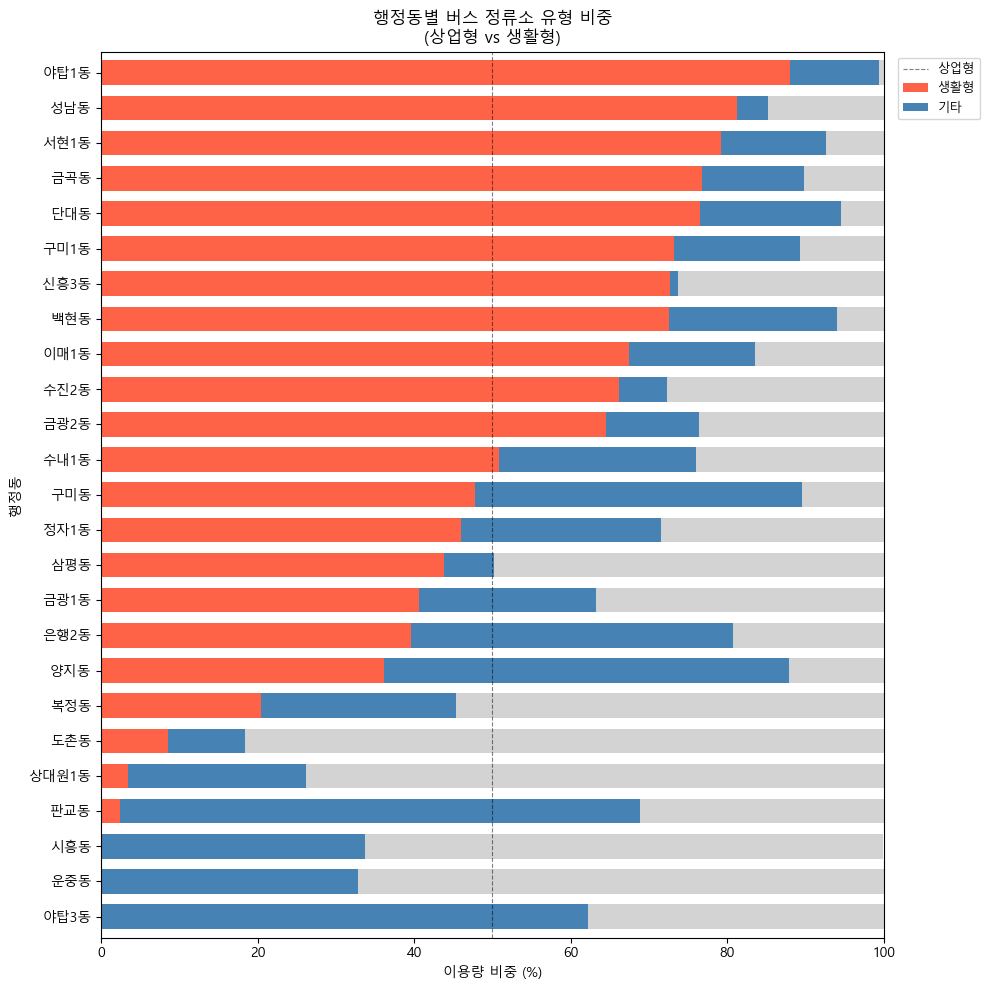

In [19]:
import matplotlib.pyplot as plt

commercial_kw = ['역', '백화점', '마트', '쇼핑', '터미널', '아울렛', '플라자', '프라자', '시장', '몰']
living_kw     = ['아파트', '주민센터', '학교', '경로당', '복지관', '보건소', '병원', '도서관', '공원', '마을', '주택']

def classify(name):
    for kw in commercial_kw:
        if kw in name:
            return '상업형'
    for kw in living_kw:
        if kw in name:
            return '생활형'
    return '기타'

df_bus['정류소유형'] = df_bus['정류소명'].apply(classify)

# 행정동 × 유형별 이용량 합산
type_df = (
    df_bus
    .groupby(['행정동', '정류소유형'])['승차합계']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=['상업형', '생활형', '기타'], fill_value=0)
)

# 총 이용량 기준 상위 25개 동만
top25 = type_df.sum(axis=1).nlargest(25).index
type_top = type_df.loc[top25]

# 비율로 변환
type_pct = type_top.div(type_top.sum(axis=1), axis=0) * 100

# 상업형 비중 기준 정렬
type_pct = type_pct.sort_values('상업형', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))

type_pct.plot(
    kind='barh', stacked=True, ax=ax,
    color=['tomato', 'steelblue', 'lightgray'],
    width=0.7
)

ax.axvline(50, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('이용량 비중 (%)', fontsize=10)
ax.set_title('행정동별 버스 정류소 유형 비중\n(상업형 vs 생활형)', fontsize=12)
ax.legend(['상업형', '생활형', '기타'], bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

### 해석

- **상업형 비중 높은 동** (오른쪽): 버스 이용자 대부분이 역·쇼핑몰 중심 이동 → 외부 소비 유입 구조 → 임대료 상승·소상공인 이탈 압력 높음
- **생활형 비중 높은 동** (왼쪽): 아파트·학교·병원 등 생활 시설 이동 중심 → 골목 상권 중심, 상업화 압력 낮음
- **기타 비중이 높은 동**: 정류소명이 시설명 없이 지명만 있는 경우 — 상권 성격 파악이 어려운 지역


## 지하철

In [20]:
import pandas as pd
import glob
import os

In [41]:
file_path = "../Data/2차전처리_지하철데이터.csv"

# 파일 존재 여부 먼저 확인
print(os.path.exists(file_path))

# True가 나오면 실행
df_subway = pd.read_csv(file_path, encoding="utf-8-sig")

df_subway.head(5)

True


,월,노선명,역명,월별_승차합계,월별_하차합계
0,2023-01,분당선,가천대,182889,200114
1,2023-01,8호선,남위례,159937,165440
2,2023-01,8호선,남한산성입구(성남법원.검찰청),349153,313708
3,2023-01,8호선,단대오거리,312021,304362
4,2023-01,8호선,모란,131234,106478


In [ ]:
#  역명 → 행정동 매핑 (동만)
station_dong_map = {
    ('분당선', '오리'): '구미동',
    ('분당선', '미금'): '구미동',
    ('분당선', '정자'): '정자동',
    ('분당선', '수내'): '수내동',
    ('분당선', '서현'): '서현동',
    ('분당선', '이매'): '이매동',
    ('분당선', '야탑'): '야탑동',
    ('분당선', '모란'): '성남동',
    ('분당선', '태평'): '태평동',
    ('분당선', '가천대'): '태평동',

    ('8호선', '복정'): '복정동',
    ('8호선', '남위례'): '복정동',
    ('8호선', '산성'): '산성동',
    ('8호선', '남한산성입구(성남법원.검찰청)'): '단대동',
    ('8호선', '단대오거리'): '단대동',
    ('8호선', '신흥'): '신흥동',
    ('8호선', '수진'): '수진동',
    ('8호선', '모란'): '수진동',

    ('경강선', '판교'): '백현동',
    ('경강선', '성남'): '백현동',
    ('경강선', '이매'): '이매동',

    ('신분당선', '판교'): '백현동',
    ('신분당선', '정자'): '정자동',
    ('신분당선', '미금'): '금곡동'
}


# 🔹 행정동 컬럼 추가
df_subway['행정동'] = df_subway.apply(
    lambda row: station_dong_map.get((row['노선명'], row['역명'])),
    axis=1
)


# 🔹 확인
df_subway.head(5)

,월,노선명,역명,월별_승차합계,월별_하차합계,행정동
0,2023-01,분당선,가천대,182889,200114,태평동
1,2023-01,8호선,남위례,159937,165440,복정동
2,2023-01,8호선,남한산성입구(성남법원.검찰청),349153,313708,단대동
3,2023-01,8호선,단대오거리,312021,304362,단대동
4,2023-01,8호선,모란,131234,106478,수진동


## 역별 분기별 시계열 추이

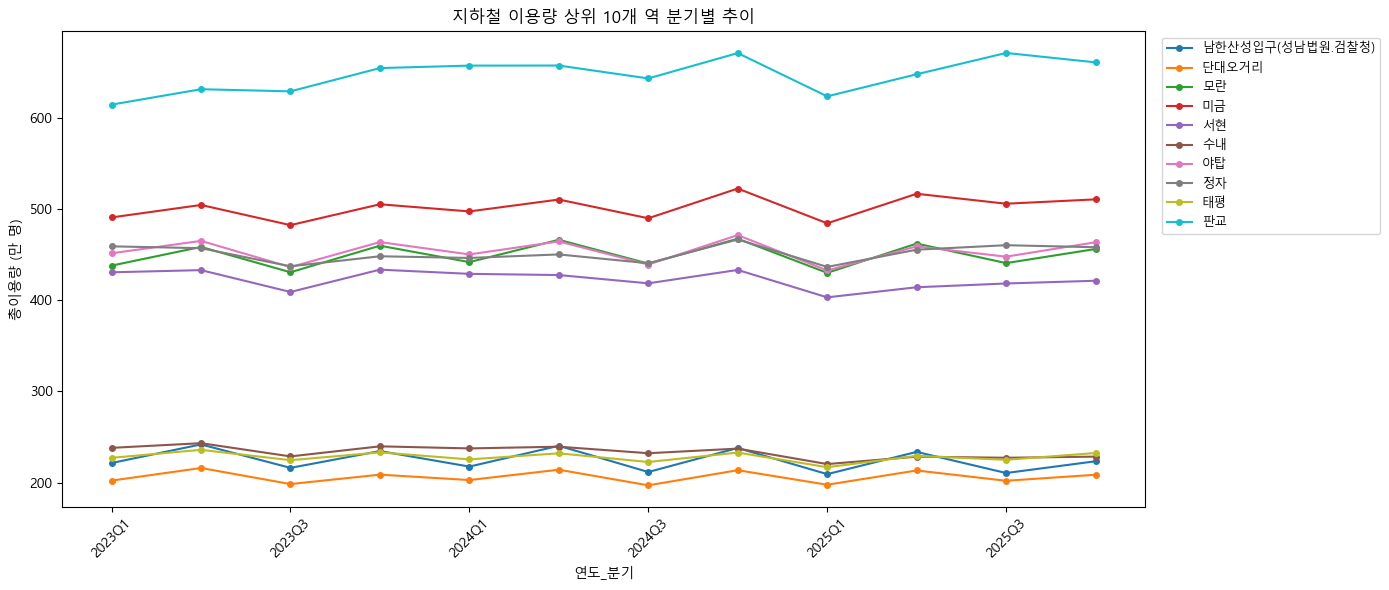

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 변환 + 분기 컬럼
df_subway["월"] = pd.to_datetime(df_subway["월"])
df_subway["연도_분기"] = df_subway["월"].dt.to_period("Q").astype(str)

# 총이용량 = 승차 + 하차
df_subway["총이용량"] = df_subway["월별_승차합계"] + df_subway["월별_하차합계"]

# 역별 분기별 집계
station_q = (
    df_subway
    .groupby(["역명", "연도_분기"])[["총이용량", "월별_승차합계", "월별_하차합계"]]
    .sum()
    .reset_index()
)

# 평균 분기 이용량 기준 상위 10개 역
top10_stations = (
    station_q.groupby("역명")["총이용량"]
    .mean()
    .nlargest(10)
    .index.tolist()
)

pivot = (
    station_q[station_q["역명"].isin(top10_stations)]
    .pivot(index="연도_분기", columns="역명", values="총이용량") / 1e4
)

pivot.plot(figsize=(14, 6), marker="o", ms=4)
plt.title("지하철 이용량 상위 10개 역 분기별 추이", fontsize=12)
plt.ylabel("총이용량 (만 명)")
plt.xlabel("연도_분기")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 노선별 분기별 시계열 추이

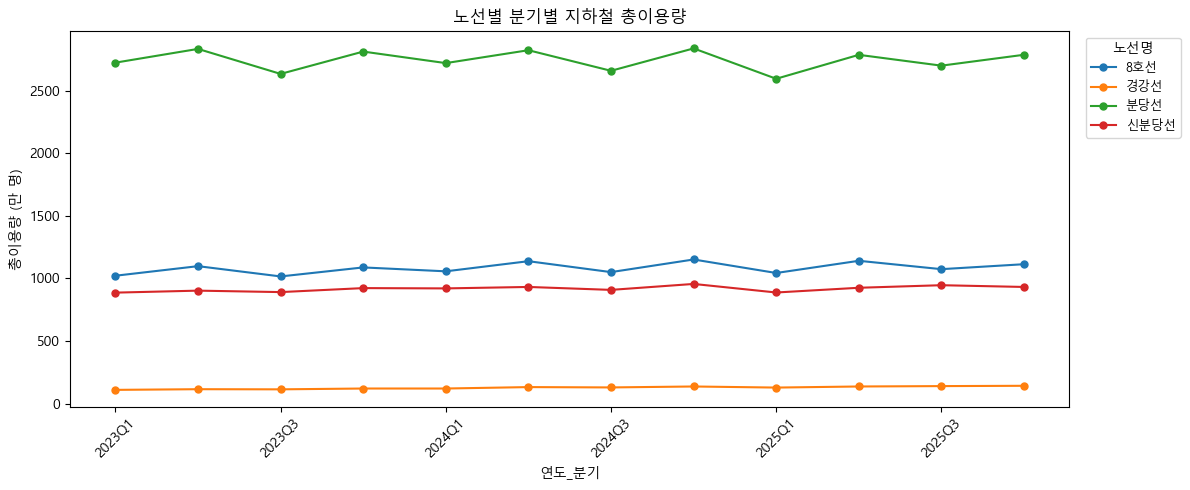

In [23]:
# 노선별 분기별 집계
line_q = (
    df_subway
    .groupby(["노선명", "연도_분기"])["총이용량"]
    .sum()
    .reset_index()
)

pivot_line = (
    line_q
    .pivot(index="연도_분기", columns="노선명", values="총이용량") / 1e4
)

pivot_line.plot(figsize=(12, 5), marker="o", ms=5)
plt.title("노선별 분기별 지하철 총이용량", fontsize=12)
plt.ylabel("총이용량 (만 명)")
plt.xlabel("연도_분기")
plt.xticks(rotation=45)
plt.legend(title="노선명", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 역별 승차 vs 하차 분기별 비교 (상위 5개 역)

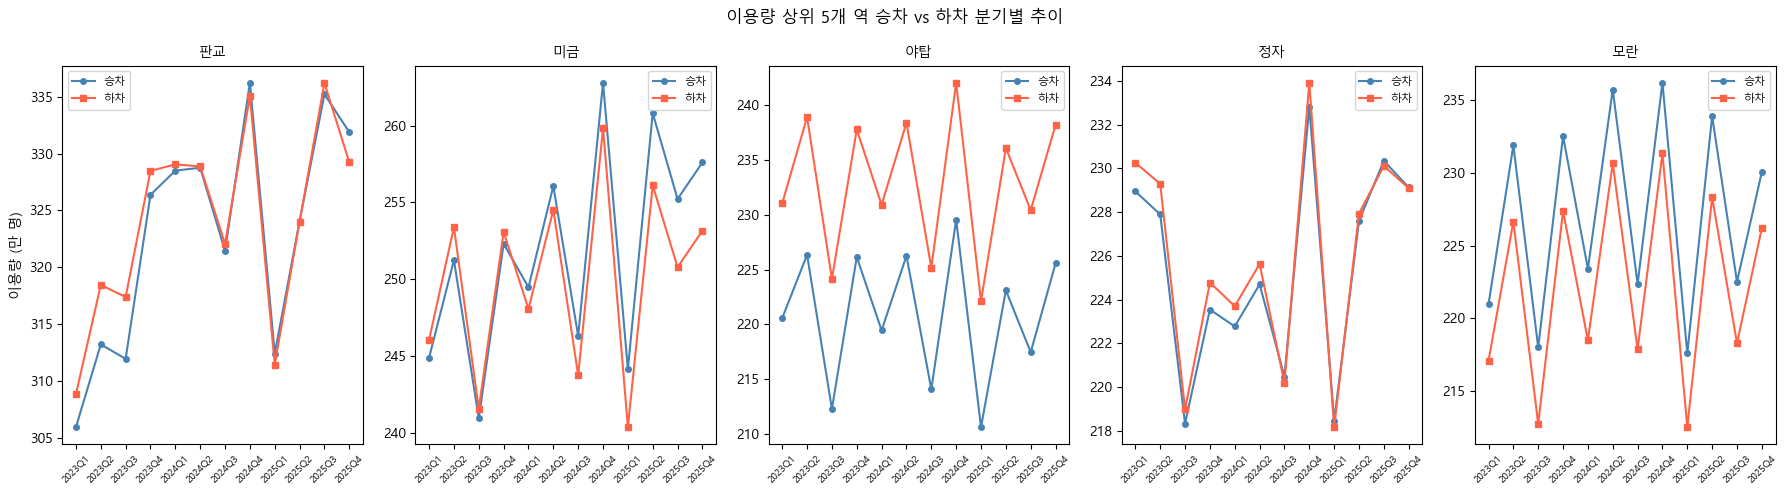

In [24]:
top5_stations = (
    station_q.groupby("역명")["총이용량"]
    .mean()
    .nlargest(5)
    .index.tolist()
)

fig, axes = plt.subplots(1, len(top5_stations), figsize=(18, 5), sharey=False)

for ax, station in zip(axes, top5_stations):
    sub = station_q[station_q["역명"] == station].set_index("연도_분기")
    ax.plot(sub.index, sub["월별_승차합계"] / 1e4, marker="o", ms=4, label="승차", color="steelblue")
    ax.plot(sub.index, sub["월별_하차합계"] / 1e4, marker="s", ms=4, label="하차", color="tomato")
    ax.set_title(station, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=8)

axes[0].set_ylabel("이용량 (만 명)")
fig.suptitle("이용량 상위 5개 역 승차 vs 하차 분기별 추이", fontsize=12)
plt.tight_layout()
plt.show()

### 해석 포인트

- 하차 > 승차 → 야탑  
  → 외부 유입 중심 (상업지, 소비 발생, 임대료 상승 압력)

- 승차 > 하차 → 해당 없음 (일부 판교)  
  → 출발지 성격 (주거 중심, 소비 외부 유출 가능)

- 승차 ≈ 하차 → 미금, 정자  
  → 자족형 구조 (생활·소비 내부 순환, 안정 상권)
- 분기별로 하차 비중이 늘어나는 역 = 젠트리피케이션 진행 중인 상권 신호

## 행정동별 시계열 추이 (지하철)

- 성남시 내 지하철역이 위치한 행정동 단위로 월별 / 분기별 총이용량 추이를 비교
- 총이용량 = 월별_승차합계 + 월별_하차합계

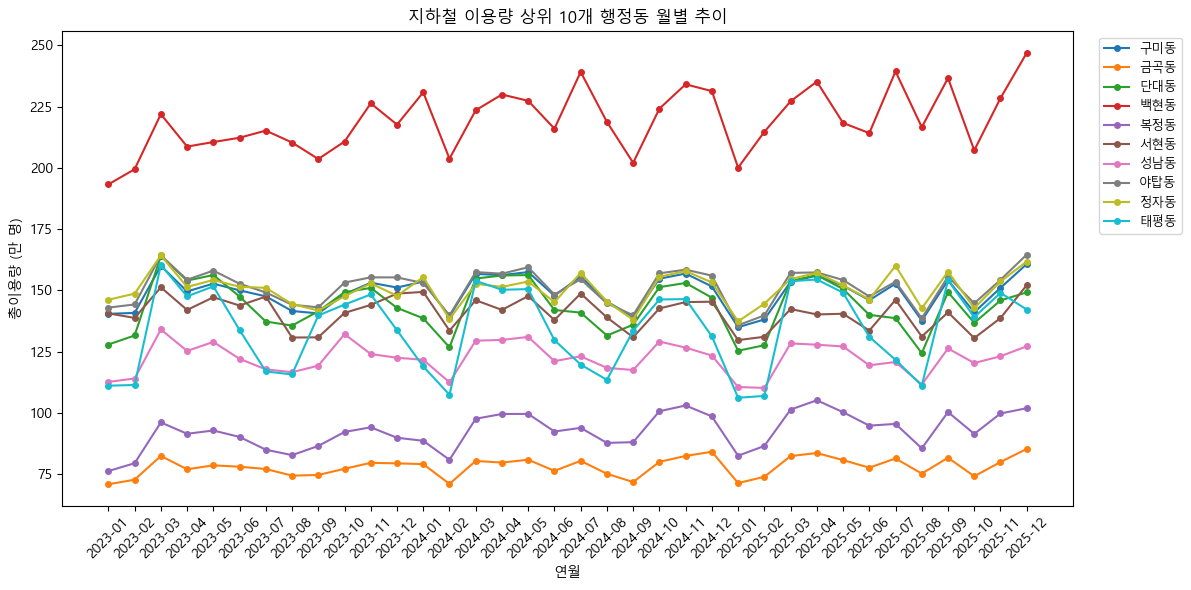

In [51]:
# 1. 행정동 × 월별 지하철 총이용량
dong_m_sub = (
    df_subway.dropna(subset=["행정동"])
    .groupby(["행정동", "월"])["총이용량"]
    .sum()
    .reset_index()
)

# 2. 평균 월 이용량 기준 상위 10개 동
top10_dong = (
    dong_m_sub.groupby("행정동")["총이용량"]
    .mean()
    .nlargest(10)
    .index.tolist()
)

# 3. pivot (만 명 단위)
dong_pivot_m = (
    dong_m_sub[dong_m_sub["행정동"].isin(top10_dong)]
    .pivot(index="월", columns="행정동", values="총이용량") / 1e4
)

# 4. 시각화
plt.figure(figsize=(12, 6))
for dong in dong_pivot_m.columns:
    plt.plot(dong_pivot_m.index, dong_pivot_m[dong], marker="o", ms=4, label=dong)
plt.title("지하철 이용량 상위 10개 행정동 월별 추이", fontsize=12)
plt.xlabel("연월")
plt.ylabel("총이용량 (만 명)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

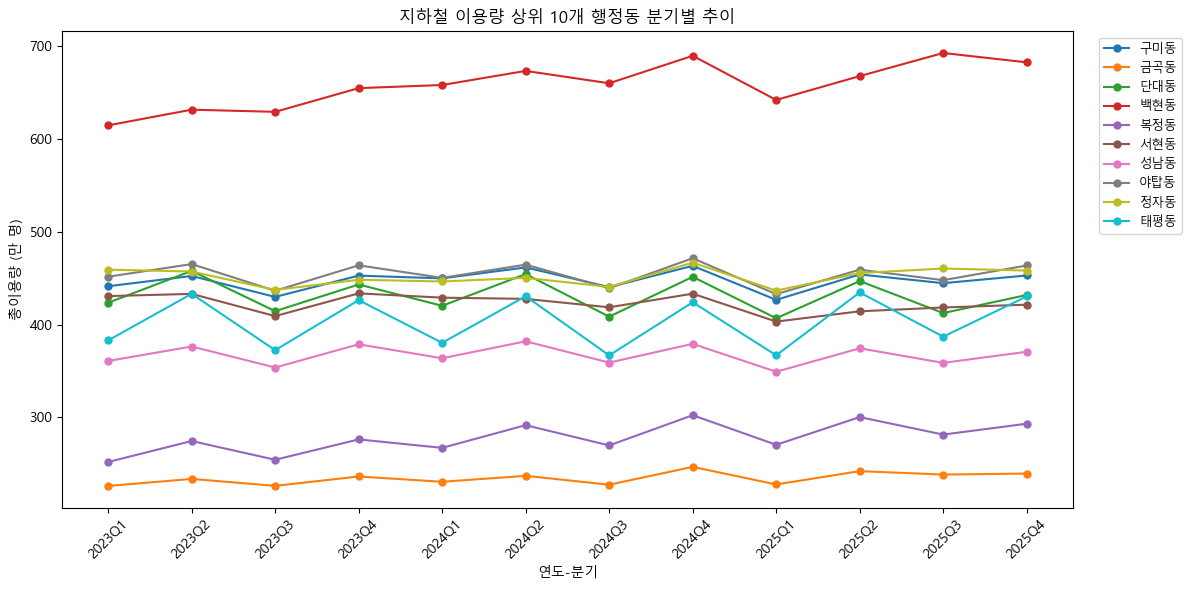

In [52]:
# 1. 행정동 × 분기별 지하철 총이용량
dong_q_sub = (
    df_subway.dropna(subset=["행정동"])
    .groupby(["행정동", "연도_분기"])["총이용량"]
    .sum()
    .reset_index()
)

# 2. 평균 분기 이용량 기준 상위 10개 동
top10_dong_q = (
    dong_q_sub.groupby("행정동")["총이용량"]
    .mean()
    .nlargest(10)
    .index.tolist()
)

# 3. pivot (만 명 단위)
dong_pivot_q = (
    dong_q_sub[dong_q_sub["행정동"].isin(top10_dong_q)]
    .pivot(index="연도_분기", columns="행정동", values="총이용량") / 1e4
)

# 4. 시각화
plt.figure(figsize=(12, 6))
for dong in dong_pivot_q.columns:
    plt.plot(dong_pivot_q.index, dong_pivot_q[dong], marker="o", ms=5, label=dong)
plt.title("지하철 이용량 상위 10개 행정동 분기별 추이", fontsize=12)
plt.xlabel("연도-분기")
plt.ylabel("총이용량 (만 명)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

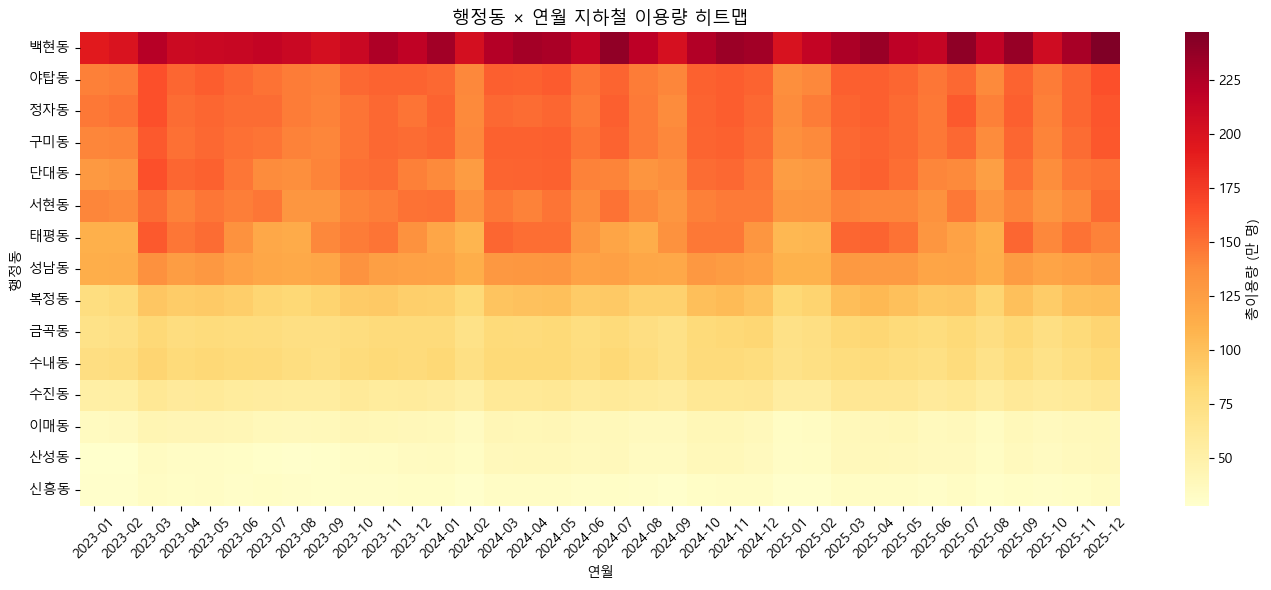

In [54]:
# 행정동 × 연월 히트맵 (지하철)
import seaborn as sns

heat = (
    dong_m_sub
    .pivot(index="행정동", columns="월", values="총이용량")
    .fillna(0) / 1e4
)

# 평균 이용량 기준 정렬
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

# x축 라벨용 (YYYY-MM)
df_subway["연도_분기"] = pd.to_datetime(df_subway["월"]).dt.to_period("Q").astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heat,
    cmap="YlOrRd",
    cbar_kws={"label": "총이용량 (만 명)"},
    ax=ax,
)
ax.set_title("행정동 × 연월 지하철 이용량 히트맵", fontsize=13)
ax.set_xlabel("연월")
ax.set_ylabel("행정동")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 해석 포인트

- 상위 행정동은 환승 거점 / 업무·상업 중심에 해당
- 동별 추이의 기울기 차이 → 상권 활력 격차 신호
- 전반적으로 우상향이면 외부 유입 증가, 횡보 / 하락이면 정체 또는 이탈

## 역별 지하철 이용량 로그 변화율 (시작 분기 vs 최종 분기)

- 기준: 분석 시작 분기(2023Q1) 대비 최종 분기 총이용량 변화를 로그 변화율로 측정
- 파란색 -> 소비자 유입 증가 / 빨간색 -> 소비자 이탈

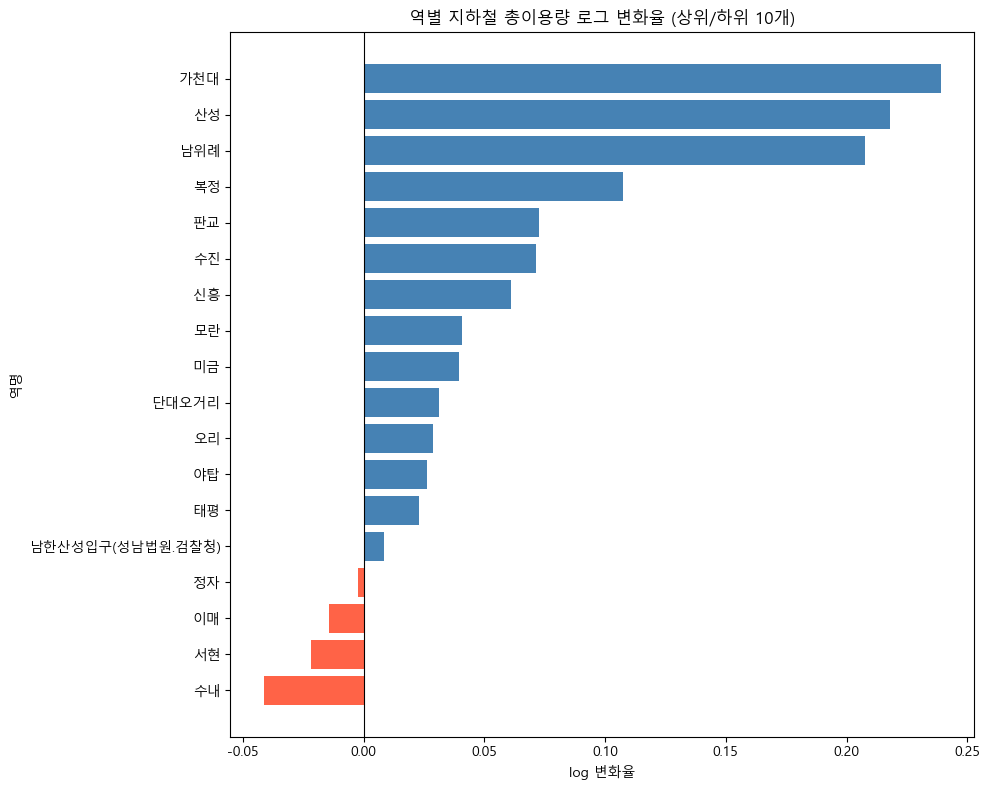

=== 증가 상위 10개 역 ===
       log_rate
역명             
가천대       0.239
산성        0.218
남위례       0.208
복정        0.107
판교        0.073
수진        0.072
신흥        0.061
모란        0.041
미금        0.040
단대오거리     0.031
=== 감소 하위 10개 역 ===
                  log_rate
역명                        
미금                   0.040
단대오거리                0.031
오리                   0.029
야탑                   0.026
태평                   0.023
남한산성입구(성남법원.검찰청)     0.009
정자                  -0.002
이매                  -0.014
서현                  -0.022
수내                  -0.041


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 역별 시작/끝 분기
station_start = station_q.sort_values("연도_분기").groupby("역명").first()
station_end   = station_q.sort_values("연도_분기").groupby("역명").last()

# 0 방지
station_start = station_start.replace(0, np.nan)
station_end   = station_end.replace(0, np.nan)

# df_log 생성 (모든 지표 한번에)
df_log = pd.DataFrame({
    "총_start":  station_start["총이용량"],
    "총_end":    station_end["총이용량"],
    "승차_start": station_start["월별_승차합계"],
    "승차_end":   station_end["월별_승차합계"],
    "하차_start": station_start["월별_하차합계"],
    "하차_end":   station_end["월별_하차합계"],
})

# 소규모 역 제거 (분기 총이용량 10만 미만)
df_log = df_log[df_log["총_start"] > 100_000].copy()

# 로그 변화율 3종
df_log["log_rate"]      = np.log(df_log["총_end"]   / df_log["총_start"])
df_log["log_rate_승차"] = np.log(df_log["승차_end"] / df_log["승차_start"])
df_log["log_rate_하차"] = np.log(df_log["하차_end"] / df_log["하차_start"])
df_log["하차우세"]       = df_log["log_rate_하차"] - df_log["log_rate_승차"]

# ---- 시각화: 총이용량 로그 변화율 ----
sorted_df = df_log.sort_values("log_rate", ascending=False)
plot_df   = pd.concat([sorted_df.head(10), sorted_df.tail(10)])
colors    = ["steelblue" if x > 0 else "tomato" for x in plot_df["log_rate"]]

plt.figure(figsize=(10, 8))
plt.barh(plot_df.index, plot_df["log_rate"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("역별 지하철 총이용량 로그 변화율 (상위/하위 10개)")
plt.xlabel("log 변화율")
plt.ylabel("역명")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("=== 증가 상위 10개 역 ===")
print(sorted_df.head(10)[["log_rate"]].round(3).to_string())
print("=== 감소 하위 10개 역 ===")
print(sorted_df.tail(10)[["log_rate"]].round(3).to_string())

- 전체 역 이용량 증가 → 도시 전체 유동 인구 증가

- 상위 역 → 증가 폭 큼  
  → 유입 집중 → 상권 활성화 → 임대료 상승 (젠트리피케이션 진행)

- 하위 역 → 증가 폭 작음  
  → 상대적 정체 → 상권 경쟁력 약화

-> 결론:  **유동 인구가 특정 역에 집중되면서 상권 양극화 발생**

## 승차 vs 하차 로그 변화율 비교

- 승차 증가: 거주/통근 인구 변화
- 하차 증가: 소비 유입 증가 -> 상권 활성화 신호
- **하차우세 양수**: 소비 목적 유입이 통근보다 빠르게 증가

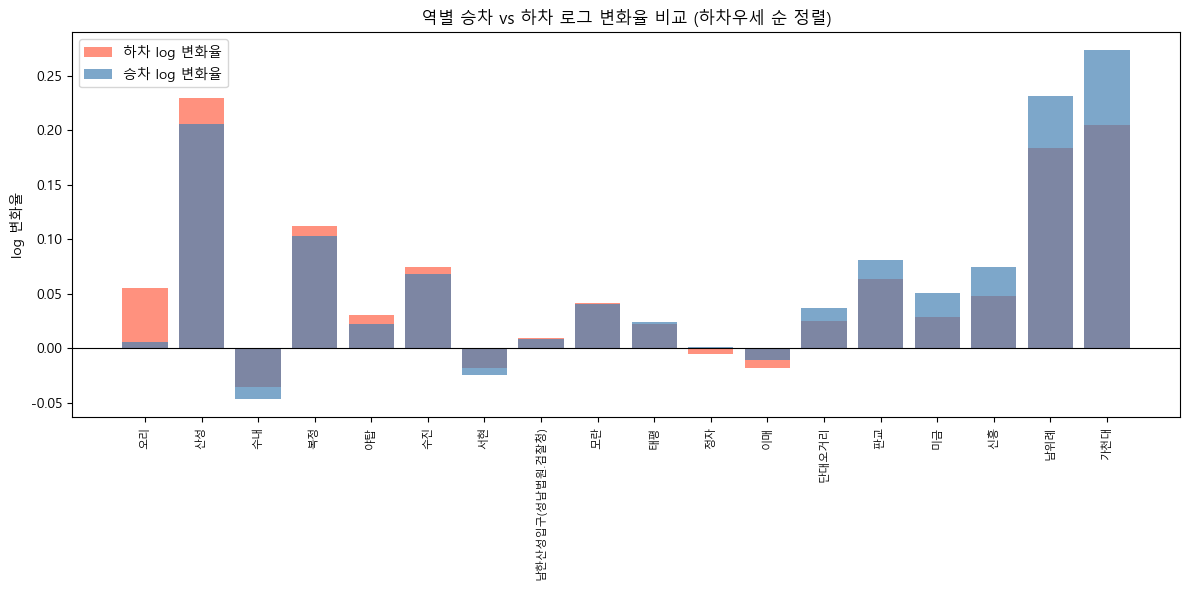

=== 하차 증가가 승차보다 큰 역 (소비 유입 우세) ===
                  log_rate_승차  log_rate_하차   하차우세
역명                                               
오리                      0.006        0.055  0.049
산성                      0.206        0.230  0.023
수내                     -0.047       -0.036  0.011
복정                      0.103        0.113  0.009
야탑                      0.022        0.030  0.008
수진                      0.068        0.075  0.007
서현                     -0.025       -0.018  0.006
남한산성입구(성남법원.검찰청)        0.008        0.009  0.001
모란                      0.040        0.041  0.001


In [26]:
plot2 = df_log.sort_values("하차우세", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(plot2))
ax.bar(x, plot2["log_rate_하차"], label="하차 log 변화율", color="tomato", alpha=0.7)
ax.bar(x, plot2["log_rate_승차"], label="승차 log 변화율", color="steelblue", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(plot2.index, rotation=90, fontsize=8)
ax.set_ylabel("log 변화율")
ax.set_title("역별 승차 vs 하차 로그 변화율 비교 (하차우세 순 정렬)")
ax.legend()
plt.tight_layout()
plt.show()

print("=== 하차 증가가 승차보다 큰 역 (소비 유입 우세) ===")
print(
    plot2[plot2["하차우세"] > 0]
    [["log_rate_승차", "log_rate_하차", "하차우세"]]
    .round(3)
    .to_string()
)

## 분기별 전분기 대비 승하차 변화율 (QoQ)

- 전분기 대비 몇 % 변했는지 추이
- 승차/하차 변화율이 같이 오르면 유동인구 실제 증가
- 하차만 오르면 소비 유입 집중 신호

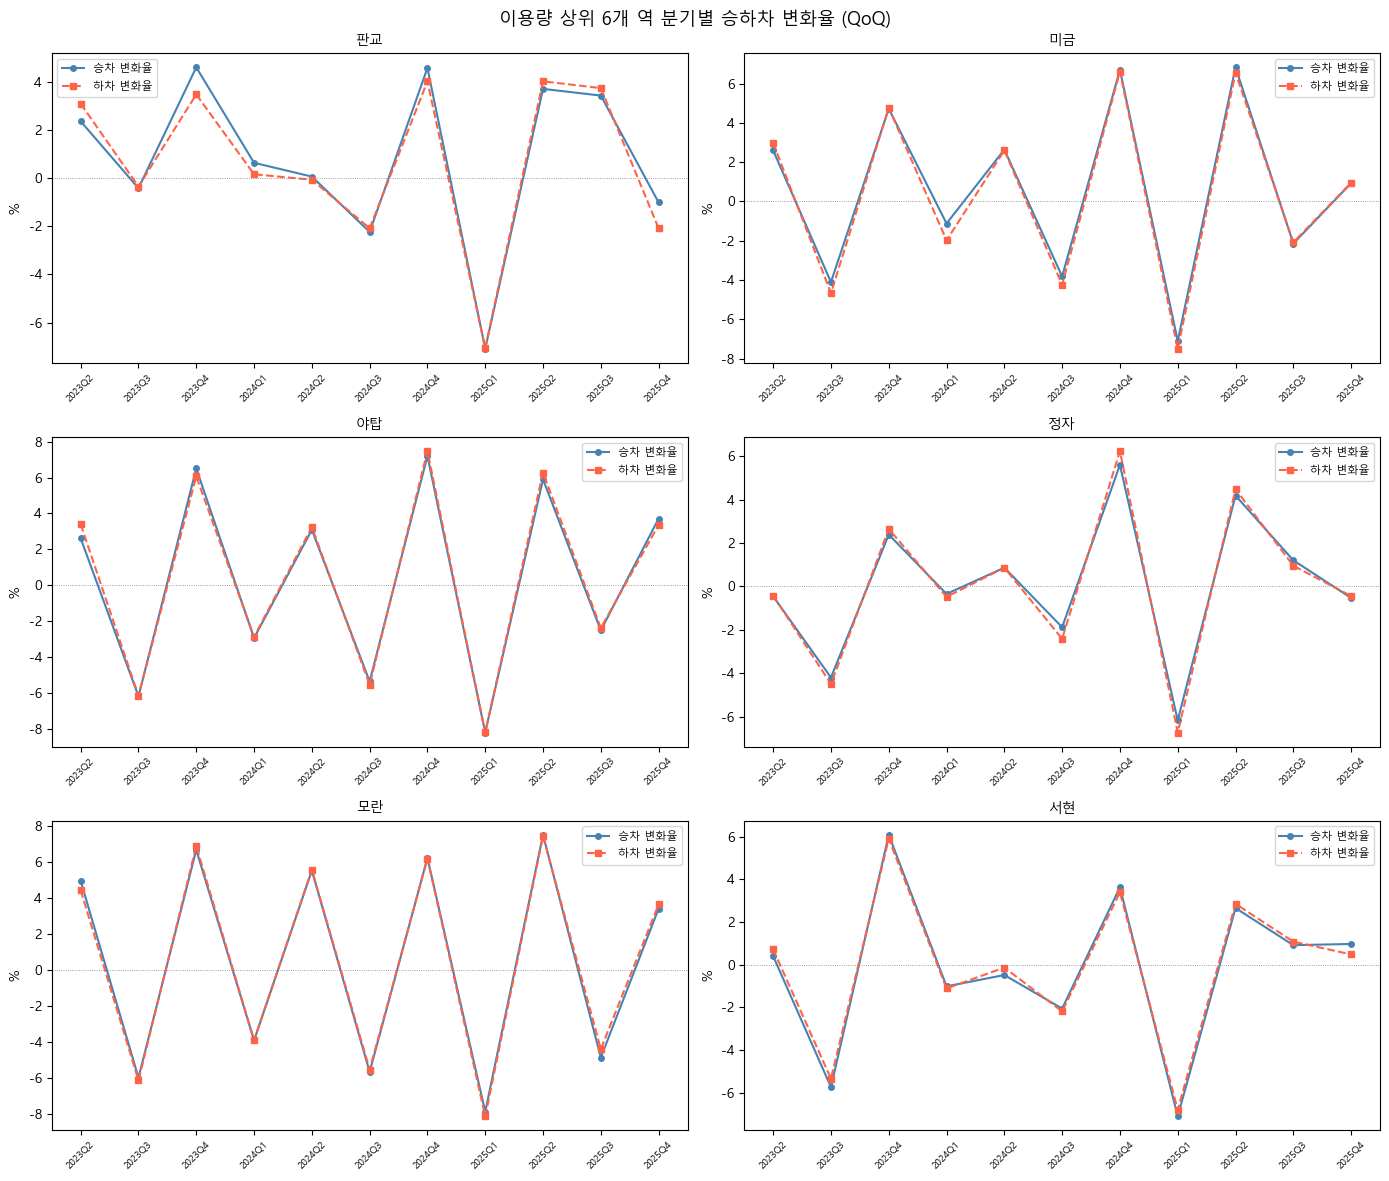

In [27]:
# 역별 분기별 pivot
pivot_board = (
    station_q.pivot(index="연도_분기", columns="역명", values="월별_승차합계")
)
pivot_alight = (
    station_q.pivot(index="연도_분기", columns="역명", values="월별_하차합계")
)

# 전분기 대비 변화율 (%)
qoq_board  = pivot_board.pct_change()  * 100
qoq_alight = pivot_alight.pct_change() * 100

# 상위 6개 역만 시각화
top6 = (
    station_q.groupby("역명")["총이용량"].mean()
    .nlargest(6).index.tolist()
)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=False)
axes = axes.flatten()

for ax, station in zip(axes, top6):
    if station not in qoq_board.columns:
        continue
    ax.plot(qoq_board.index,  qoq_board[station],  marker="o", ms=4,
            label="승차 변화율", color="steelblue")
    ax.plot(qoq_alight.index, qoq_alight[station], marker="s", ms=4,
            label="하차 변화율", color="tomato", linestyle="--")
    ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
    ax.set_title(station, fontsize=10)
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=8)

fig.suptitle("이용량 상위 6개 역 분기별 승하차 변화율 (QoQ)", fontsize=13)
plt.tight_layout()
plt.show()

### 해석 포인트

- 승차/하차 변화율이 **같이 상승** -> 해당 역 주변 유동인구 실질 증가
- **하차만 상승 (승차 정체)** -> 외부 소비자 유입 집중 -> 임대료 상승 압력
- **승차만 상승 (하차 정체)** -> 거주/통근 인구 증가, 소비 유입은 아직 없음
- 변화율이 **큰 폭 음수** 구간 -> 해당 분기 이용 급감 (공사·노선 변경 등 외부 요인 의심)


---

### 승차/하차 변화율이 거의 같게 나오는 이유

#### 1. 지하철 네트워크의 구조적 특성
지하철은 **탄 사람은 반드시 어딘가에서 내려야 한다.** 시스템 전체로 보면 총 승차합계 = 총 하차합계가 항상 성립한다. 성남시 역들처럼 노선 중간에 위치한 역들은 이 균형이 개별 역 수준에서도 장기적으로 유지되는 경향이 있다.

#### 2. 외부 충격이 승차/하차를 동시에 움직인다
분기별 변화율을 크게 만드는 요인(명절 연휴, 계절성, 재난·감염병 등)은 승차와 하차에 **동시에** 같은 방향으로 영향을 준다. 예를 들어 추석 연휴가 긴 분기에는 역 이용 자체가 줄어서 승차도 ↓ 하차도 ↓가 되기 때문에 변화율 곡선이 겹친다.

#### 3. 분기 집계로 인한 평균화
월별 데이터를 분기로 합산하면서 단기 노이즈가 상쇄된다. 특정 월에 하차만 튀는 이벤트가 있어도 3개월 합산하면 희석된다.

#### 4. 버스와의 근본적 차이
버스 데이터에는 **초승(처음 탑승) / 환승** 구분이 있어서 성격 차이가 뚜렷하게 나온다. 지하철은 단순 승차/하차만 집계하므로 이런 구분이 없다.

## 역별 평균 하차비율 비교 (막대 차트)

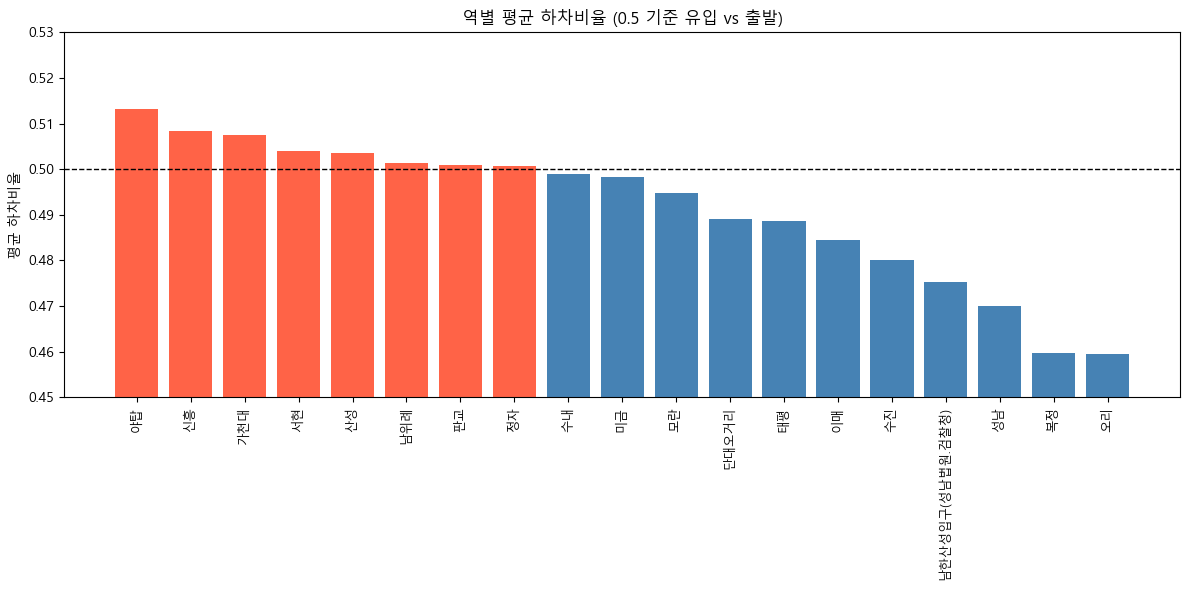

In [ ]:
avg_ratio = (
    station_q.groupby("역명")["하차비율"]
    .mean()
    .sort_values(ascending=False)
)

diff = avg_ratio - 0.5

colors = ["tomato" if v > 0 else "steelblue" for v in diff]

plt.figure(figsize=(12, 6))
plt.bar(avg_ratio.index, avg_ratio.values, color=colors)

plt.axhline(0.5, color="black", linewidth=1.0, linestyle="--")

plt.ylim(0.45, 0.53)  

plt.xticks(rotation=90, fontsize=9)
plt.ylabel("평균 하차비율")
plt.title("역별 평균 하차비율 (0.5 기준 유입 vs 출발)")

plt.tight_layout()
plt.show()

### 해석

- **하차비율 > 0.5 (빨강)**: 도착 목적 승객 우세 -> 상업 집중, 임대료 상승 압력 높은 역
- **하차비율 < 0.5 (파랑)**: 출발 승객 우세 -> 주거/통근 기반 역, 소비 유입 적음
- **분기별로 0.5를 상향 돌파하는 역**: 상권 성격이 주거형에서 소비형으로 전환 중 -> 젠트리피케이션 초기 신호

- 야탑, 신흥, 가천대 → 하차 우세 → 외부 유입 중심 → 상업 기능 강화 가능성

- 수내, 서현, 정자 → 승차 우세  → 주거/통근 중심 → 소비 유출 구조

- 대부분 역이 0.5 근처  
  → 생활형 이동 기반 (완전한 상업지 아님)

- 즉,  일부 역만 유입 우세  → 특정 지역으로 소비 집중 시작

## 노선별 역 이용 집중도 (HHI)

- 버스 HHI와 동일한 방식: 노선 내 역별 이용량 비중의 제곱합
- HHI 높음: 한두 개 역에 이용이 집중 (허브 집중형)
- HHI 낮음: 여러 역에 이용이 고르게 분산 (생활 분산형)

 노선명      HHI  역수
 경강선 0.619985   3
신분당선 0.443903   3
 8호선 0.142640   8
 분당선 0.115719  10


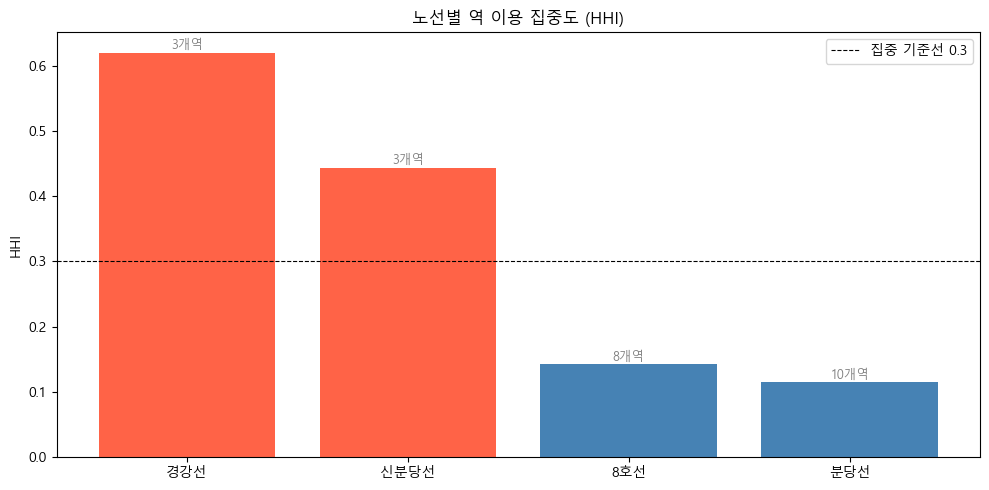

In [33]:
def calc_hhi(group):
    total = group["총이용량"].sum()
    if total == 0:
        return 0
    shares = group["총이용량"] / total
    return (shares ** 2).sum()

# 노선별 전체 기간 집계
station_total = (
    df_subway.groupby(["노선명", "역명"])["총이용량"]
    .sum()
    .reset_index()
)

hhi_line = (
    station_total
    .groupby("노선명")
    .apply(calc_hhi)
    .reset_index()
)
hhi_line.columns = ["노선명", "HHI"]

# 역 수도 같이 확인
station_cnt = station_total.groupby("노선명")["역명"].count().reset_index()
station_cnt.columns = ["노선명", "역수"]
hhi_line = hhi_line.merge(station_cnt, on="노선명").sort_values("HHI", ascending=False)

print(hhi_line.to_string(index=False))

colors = ["tomato" if h > 0.3 else "steelblue" for h in hhi_line["HHI"]]
plt.figure(figsize=(10, 5))
bars = plt.bar(hhi_line["노선명"], hhi_line["HHI"], color=colors)
for bar, cnt in zip(bars, hhi_line["역수"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{cnt}개역", ha="center", fontsize=9, color="gray")
plt.axhline(0.3, color="black", linewidth=0.8, linestyle="--", label="집중 기준선 0.3")
plt.ylabel("HHI")
plt.title("노선별 역 이용 집중도 (HHI)")
plt.legend()
plt.tight_layout()
plt.show()

### 노선별 역 이용 집중도 (HHI) 해석

**HHI = 해당 노선의 이용량이 몇 개 역에 얼마나 쏠려 있는가**

| 노선 | HHI | 구조 | 해석 |
|---|---|---|---|
| 경강선 | 높음 (~0.62) | 집중형 | 소수 핵심 역 중심 → 상권 집중, 임대료 상승 가능 |
| 신분당선 | 높음 (~0.44) | 집중형 | 허브 역 중심 구조 → 상업 기능 집중 |
| 8호선 | 낮음 (~0.14) | 분산형 | 여러 역에 이용 분산 → 생활형 상권 |
| 분당선 | 낮음 (~0.11) | 분산형 | 균형 구조 → 안정적 상권 |

**젠트리피케이션과의 연결**

- **HHI 높은 노선**: 대부분의 승객이 한두 개 허브 역에만 몰림 -> 그 역 주변만 상권이 발달하고, 나머지 역 주변 소상공인은 집객력 경쟁에서 밀려 이탈 압력 증가
- **HHI 낮은 노선**: 승객이 여러 역에 분산 -> 각 역 주변 골목 상권이 고르게 살아있는 상태

**핵심 해석**
- 집중형 노선 → 특정 역으로 유동 집중 → 상권 쏠림
- 분산형 노선 → 이용 분산 → 골목 상권 유지


## 소비 유입 증가 x 하차비율 산점도

- X축: 하차 로그 변화율 (소비 유입 증가/감소)
- Y축: 평균 하차비율 (소비 목적 유입 우세 여부)
- 기준선: X=0 (이용량 변화 없음), Y=0.5 (하차/승차 동일)


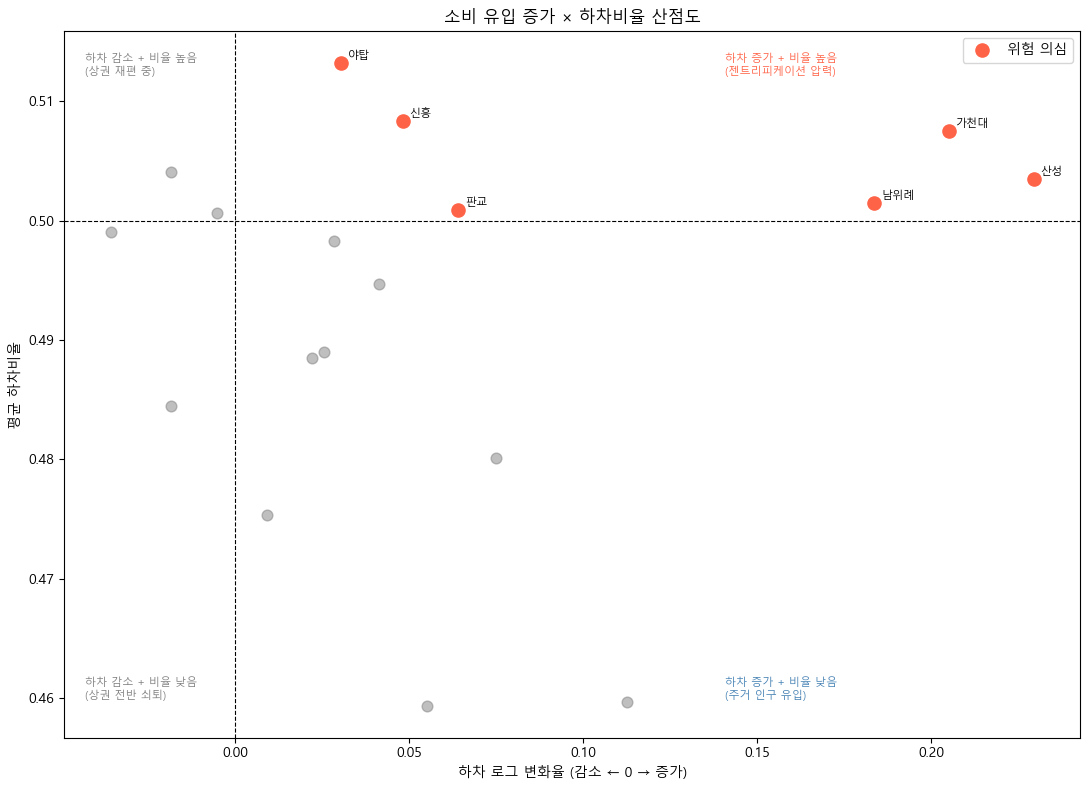

=== 위험 의심 역 ===
     log_rate_하차   하차비율
역명                     
가천대        0.205  0.508
남위례        0.184  0.501
산성         0.230  0.503
신흥         0.048  0.508
야탑         0.030  0.513
판교         0.064  0.501


In [37]:
# df_log 와 avg_ratio 합치기
avg_ratio = station_q.groupby("역명")["하차비율"].mean()

scatter_df = df_log[["log_rate_하차"]].join(avg_ratio, how="inner")
scatter_df = scatter_df.dropna()

x_med = 0
y_med = 0.5

danger = scatter_df[
    (scatter_df["log_rate_하차"] > x_med) &
    (scatter_df["하차비율"] > y_med)
]

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    scatter_df["log_rate_하차"], scatter_df["하차비율"],
    color="gray", alpha=0.5, s=60
)

ax.scatter(
    danger["log_rate_하차"], danger["하차비율"],
    color="tomato", s=90, label="위험 의심"
)

for station, row in danger.iterrows():
    ax.annotate(
        station,
        xy=(row["log_rate_하차"], row["하차비율"]),
        xytext=(5, 3),
        textcoords="offset points",
        fontsize=8
    )

ax.axvline(x_med, color="black", linewidth=0.8, linestyle="--")
ax.axhline(y_med, color="black", linewidth=0.8, linestyle="--")

# 사분면 레이블
ax.text(0.02, 0.97, "하차 감소 + 비율 높음\n(상권 재편 중)",
        transform=ax.transAxes, va="top", fontsize=8, color="gray")

ax.text(0.65, 0.97, "하차 증가 + 비율 높음\n(젠트리피케이션 압력)",
        transform=ax.transAxes, va="top", fontsize=8, color="tomato")

ax.text(0.02, 0.05, "하차 감소 + 비율 낮음\n(상권 전반 쇠퇴)",
        transform=ax.transAxes, va="bottom", fontsize=8, color="gray")

ax.text(0.65, 0.05, "하차 증가 + 비율 낮음\n(주거 인구 유입)",
        transform=ax.transAxes, va="bottom", fontsize=8, color="steelblue")

ax.set_xlabel("하차 로그 변화율 (감소 ← 0 → 증가)")
ax.set_ylabel("평균 하차비율")
ax.set_title("소비 유입 증가 × 하차비율 산점도")
ax.legend()

plt.tight_layout()
plt.show()

print("=== 위험 의심 역 ===")
print(danger[["log_rate_하차", "하차비율"]].round(3).to_string())

 사분면 | 해석 |
|---|---|
| 우상단 (하차 증가 + 비율 높음) | 소비 유입 증가 + 도착 목적 우세 -> 젠트리피케이션 압력 가장 높음 |
| 우하단 (하차 증가 + 비율 낮음) | 이용량 늘었지만 통근 성격 -> 주거 인구 유입 |
| 좌상단 (하차 감소 + 비율 높음) | 이용량 줄었지만 남은 이용자는 소비 목적 -> 상권 재편 중 |
| 좌하단 (하차 감소 + 비율 낮음) | 소비자 이탈 + 통근도 감소 -> 상권 전반 쇠퇴 |

### 해석: 우상단이 젠트리피케이션과 연결되는 이유

하차 로그변화율이 양수라는 건 해당 역으로 **소비 목적 유입이 늘고 있다**는 신호다.
거기에 하차비율까지 0.5를 넘으면 **도착 목적 승객이 출발 승객보다 많다** -> 소비 허브로 기능하는 역이다.

두 조건을 동시에 만족하는 역 주변은:
- 유동인구 증가로 임대료 상승 압력
- 대형 상업시설 입점 가능성
- 골목 소상공인 집객력 약화 -> 이탈 가속

> 우상단으로 찍힌 역에서 폐업률 상승 + 임대료 상승이 같이 나타나면 젠트리피케이션 근거로 활용 가능

## 노선 내 역별 이용량 점유율

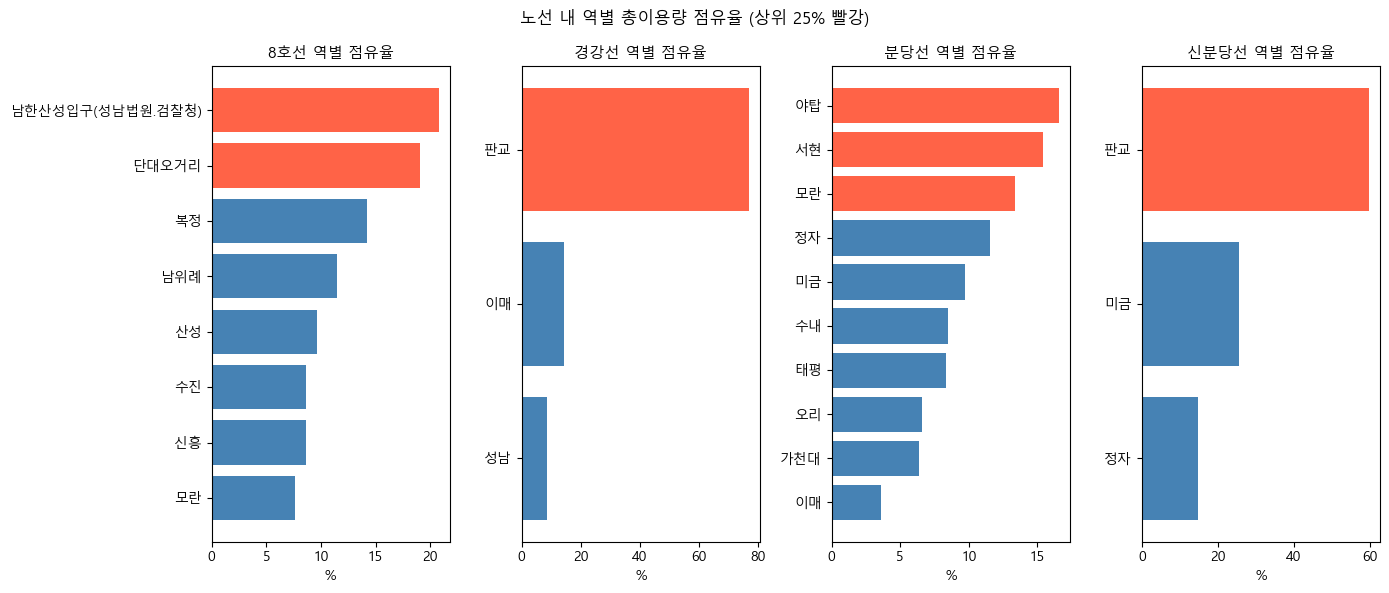

In [50]:
lines = station_total["노선명"].unique()
fig, axes = plt.subplots(1, len(lines), figsize=(14, 6))
if len(lines) == 1:
    axes = [axes]

for ax, line in zip(axes, lines):
    sub = station_total[station_total["노선명"] == line].copy()
    sub["점유율"] = sub["총이용량"] / sub["총이용량"].sum() * 100
    sub = sub.sort_values("점유율", ascending=True)
    colors_bar = ["tomato" if v >= sub["점유율"].quantile(0.75) else "steelblue" for v in sub["점유율"]]
    ax.barh(sub["역명"], sub["점유율"], color=colors_bar)
    ax.set_title(f"{line} 역별 점유율", fontsize=11)
    ax.set_xlabel("%")

plt.suptitle("노선 내 역별 총이용량 점유율 (상위 25% 빨강)", fontsize=12)
plt.tight_layout()
plt.show()

##  역 점유율 정의
- 특정 노선 전체 이용량 대비 각 역이 차지하는 비중(%)
- 예: 분당선 총 1억 명 중 야탑역 3천만 명 → 점유율 30%

## 색상 기준
- **빨강 (상위 25%)**  → 이용이 집중되는 핵심 허브 역

- **파랑 (나머지)**  → 이용이 분산된 생활형 역

## 버스 + 지하철 통합

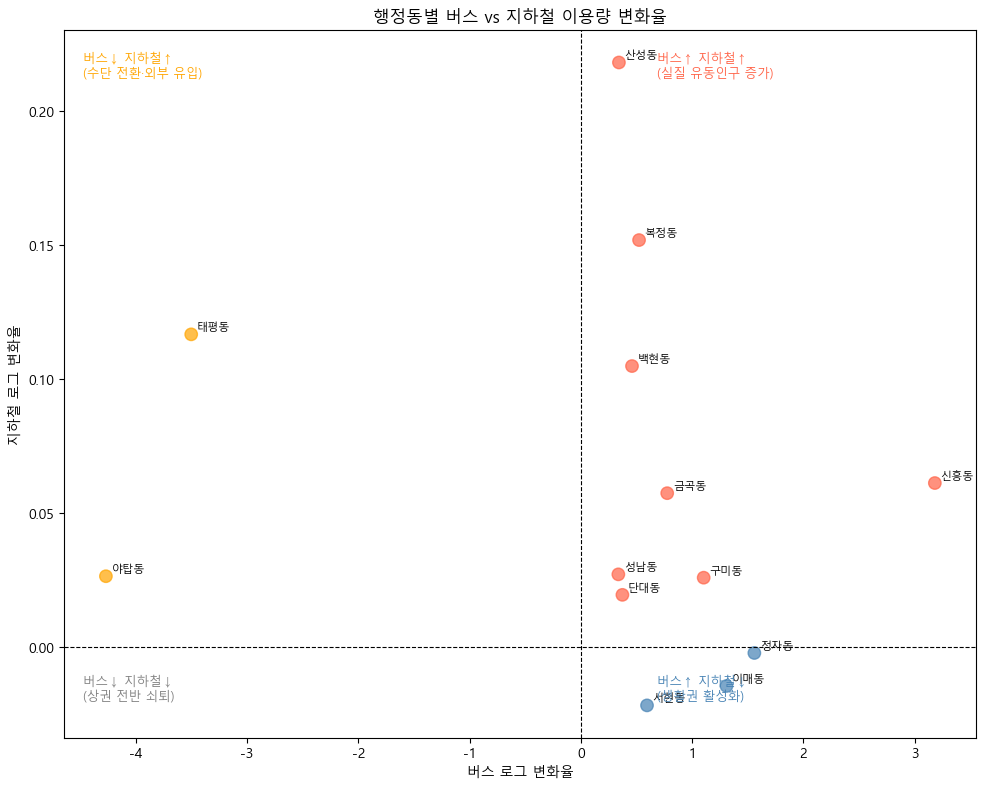

=== 위험 의심 (둘 다 증가) ===
     버스_log_rate  지하철_log_rate
행정동                           
구미동        1.104         0.026
금곡동        0.777         0.057
단대동        0.374         0.020
백현동        0.460         0.105
복정동        0.524         0.152
산성동        0.343         0.218
성남동        0.337         0.027
신흥동        3.182         0.061


In [ ]:
# 총이용량 컬럼 없으면 생성
df_subway["총이용량"] = df_subway["월별_승차합계"] + df_subway["월별_하차합계"]

# 연도_분기 컬럼 없으면 생성
df_subway["연도_분기"] = pd.to_datetime(df_subway["월"]).dt.to_period("Q").astype(str)

# 행정동별 시작/끝 분기 지하철 이용량 -> 로그 변화율
sub_dong_q = (
    df_subway.dropna(subset=["행정동"])
    .groupby(["행정동", "연도_분기"])["총이용량"]
    .sum()
    .reset_index()
)

sub_start = (
    sub_dong_q.sort_values("연도_분기")
    .groupby("행정동")
    .first()["총이용량"]
)

sub_end = (
    sub_dong_q.sort_values("연도_분기")
    .groupby("행정동")
    .last()["총이용량"]
)

sub_log = np.log(sub_end / sub_start).rename("지하철_log_rate")

# 버스 log_rate(df_rate)와 합치기
cross_df = pd.DataFrame({
    "버스_log_rate": df_rate["log_rate"],
    "지하철_log_rate": sub_log
}).dropna()

# 4분면 산점도
fig, ax = plt.subplots(figsize=(10, 8))

colors = []
for _, r in cross_df.iterrows():
    if r["버스_log_rate"] > 0 and r["지하철_log_rate"] > 0:
        colors.append("tomato")
    elif r["버스_log_rate"] < 0 and r["지하철_log_rate"] > 0:
        colors.append("orange")
    elif r["버스_log_rate"] > 0 and r["지하철_log_rate"] < 0:
        colors.append("steelblue")
    else:
        colors.append("gray")

ax.scatter(
    cross_df["버스_log_rate"],
    cross_df["지하철_log_rate"],
    c=colors,
    alpha=0.7,
    s=80
)

for dong, row in cross_df.iterrows():
    ax.annotate(
        dong,
        xy=(row["버스_log_rate"], row["지하철_log_rate"]),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8
    )

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.text(0.65, 0.97, "버스↑ 지하철↑\n(실질 유동인구 증가)",
        transform=ax.transAxes, va="top", fontsize=9, color="tomato")
ax.text(0.02, 0.97, "버스↓ 지하철↑\n(수단 전환·외부 유입)",
        transform=ax.transAxes, va="top", fontsize=9, color="orange")
ax.text(0.65, 0.05, "버스↑ 지하철↓\n(생활권 활성화)",
        transform=ax.transAxes, va="bottom", fontsize=9, color="steelblue")
ax.text(0.02, 0.05, "버스↓ 지하철↓\n(상권 전반 쇠퇴)",
        transform=ax.transAxes, va="bottom", fontsize=9, color="gray")

ax.set_xlabel("버스 로그 변화율")
ax.set_ylabel("지하철 로그 변화율")
ax.set_title("행정동별 버스 vs 지하철 이용량 변화율")

plt.tight_layout()
plt.show()

print("=== 위험 의심 (둘 다 증가) ===")
print(
    cross_df[
        (cross_df["버스_log_rate"] > 0) &
        (cross_df["지하철_log_rate"] > 0)
    ].round(3)
)

In [48]:
print("버스 행정동 수:", len(df_rate))
print("지하철 행정동 수:", len(sub_log))
print("둘 다 있는 행정동 수:", len(cross_df))

버스 행정동 수: 63
지하철 행정동 수: 15
둘 다 있는 행정동 수: 13
